Initial PINN split  1/3 done | Best epoch =  9747 | Best val loss = 7.021436e-03
Initial PINN split  2/3 done | Best epoch =  1368 | Best val loss = 1.670443e-02
Initial PINN split  3/3 done | Best epoch =  3844 | Best val loss = 1.580046e-03
PINN-sigma repeat  1/5 done | Best epoch = 1788 | Best val loss = -5.001126e+00
PINN-sigma repeat  2/5 done | Best epoch =  922 | Best val loss = -4.986041e+00
PINN-sigma repeat  3/5 done | Best epoch =   80 | Best val loss = -4.196546e+00
PINN-sigma repeat  4/5 done | Best epoch = 1999 | Best val loss = -4.591915e+00
PINN-sigma repeat  5/5 done | Best epoch = 1999 | Best val loss = -3.986299e+00
TRUE-sigma repeat  1/5 done | Best epoch = 1216 | Best val loss = -4.842373e+00
TRUE-sigma repeat  2/5 done | Best epoch =  157 | Best val loss = -4.171310e+00
TRUE-sigma repeat  3/5 done | Best epoch =  419 | Best val loss = -5.788394e+00
TRUE-sigma repeat  4/5 done | Best epoch =  363 | Best val loss = -3.712987e+00
TRUE-sigma repeat  5/5 done | Best ep

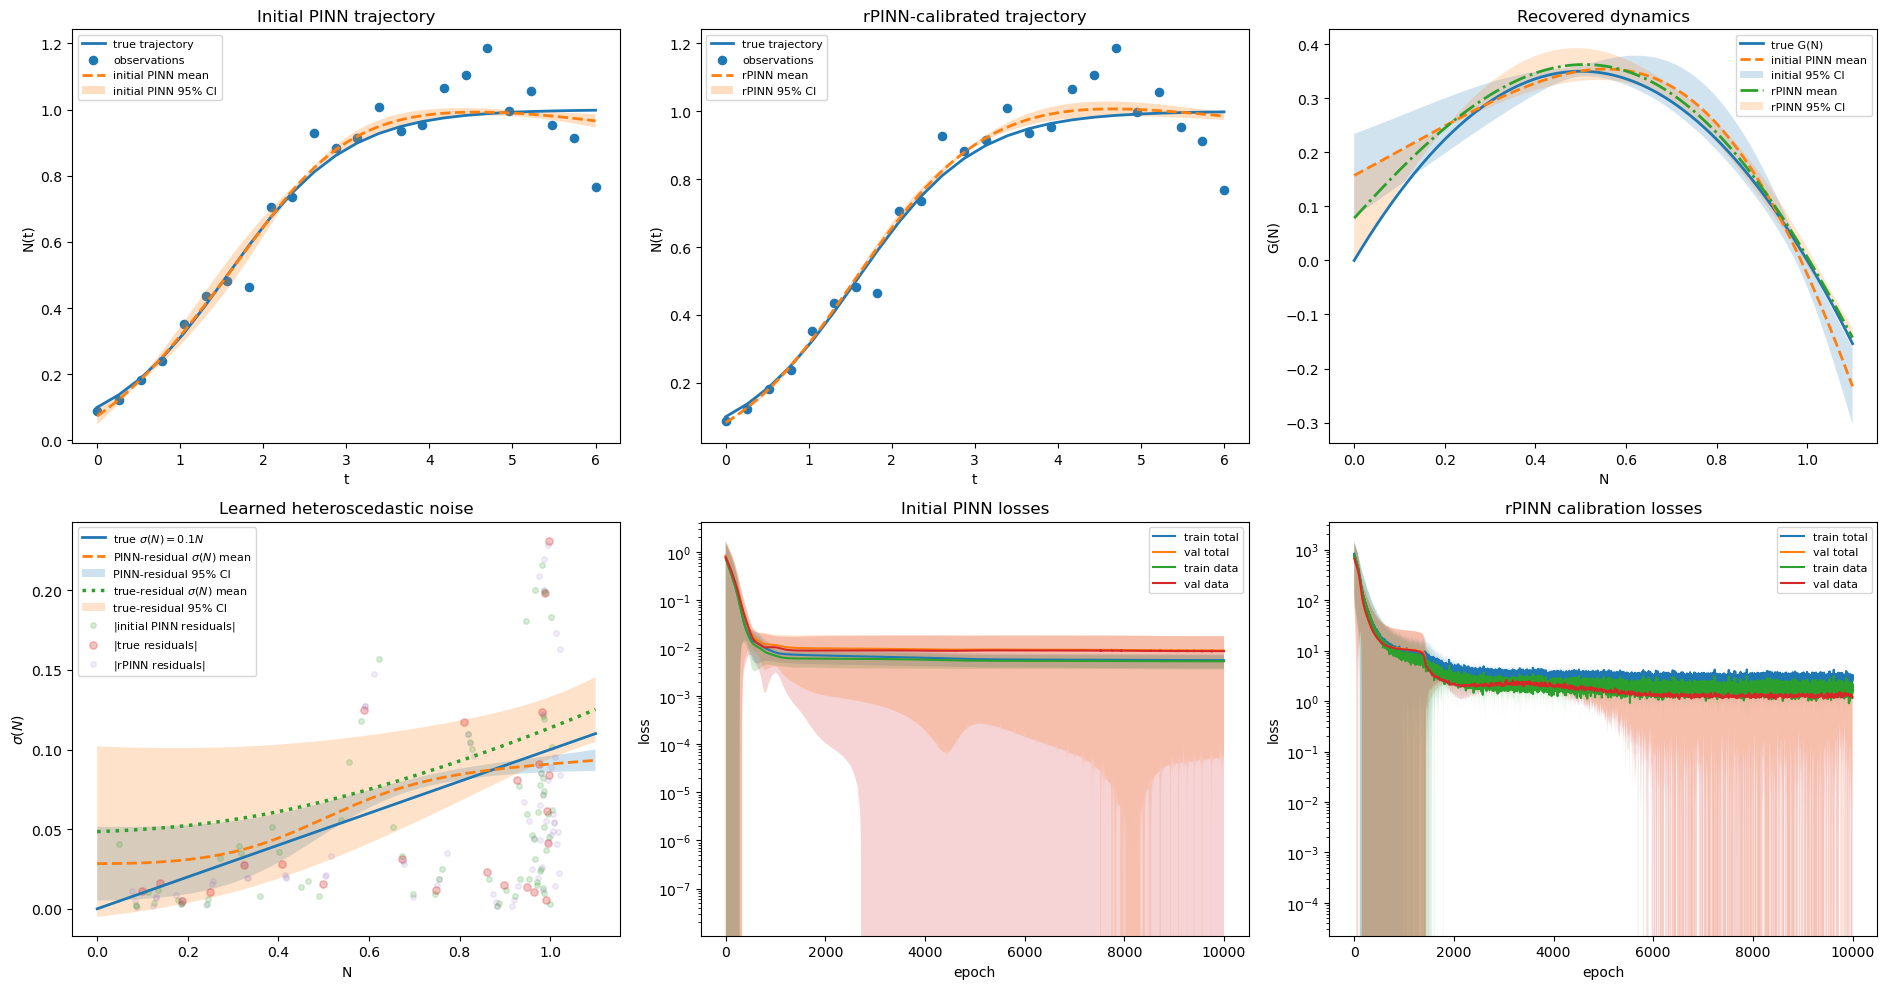

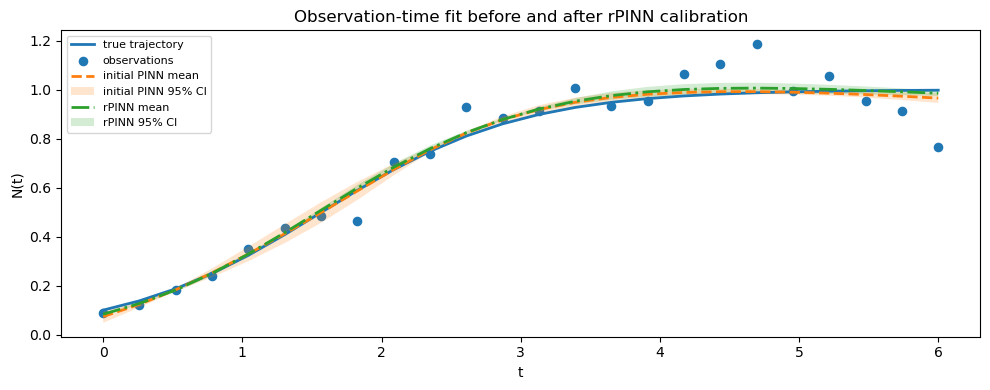


Initial PINN summary
--------------------
Number of PINN splits: 3
Mean best validation loss: 8.435302e-03
Std  best validation loss: 7.660677e-03
Mean best epoch: 4986.33
Std  best epoch: 4304.72

PINN-residual sigma summary
---------------------------
Number of sigma repeats: 5
Mean best validation loss: -4.552385e+00
Std  best validation loss: 4.577289e-01
Mean best epoch: 1357.60
Std  best epoch: 841.14

True-residual sigma summary
---------------------------
Number of sigma repeats: 5
Mean best validation loss: -4.262582e+00
Std  best validation loss: 1.131381e+00
Mean best epoch: 450.40
Std  best epoch: 448.82

rPINN calibration summary
-------------------------
Number of rPINN splits: 3
Mean best validation loss: 1.057013e+00
Std  best validation loss: 1.063050e+00
Mean best epoch: 7930.33
Std  best epoch: 479.40

Observed time points: initial PINN mean vs rPINN mean
t =  0.000 | true =  0.10000 | data =  0.08874 | PINN =  0.07369 | rPINN =  0.08322
t =  0.261 | true =  0.13800

In [16]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
# ============================================================
r_true = 1.4
N0 = 0.1
numpts = 4 * (24 // 4)

t_obs = torch.linspace(0.0, 6.0, numpts, device=device).view(-1, 1)

def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# 2. Generate synthetic observed data
#    Noise law is heteroscedastic: sigma_true(N) = 0.1 N
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)

with torch.no_grad():
    y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
    y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)

torch.manual_seed(0)
y_data = y_true + 0.1 * torch.randn_like(y_true) * y_true

# evaluation grids
t_plot = torch.linspace(0.0, 6.0, 200, device=device).view(-1, 1)
N_grid = torch.linspace(0.0, 1.1, 200, device=device).view(-1, 1)

with torch.no_grad():
    G_grid_true = G_true(N_grid)
    sigma_true_grid = 0.1 * N_grid


# ============================================================
# 3. Model classes
# ============================================================
class SolutionNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, t):
        return self.net(t)


class DynamicsNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, N):
        return self.net(N)


class SigmaNet(nn.Module):
    def __init__(self, hidden_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
            nn.Softplus(),
        )

    def forward(self, N):
        return self.net(N) + 1e-4


# ============================================================
# 4. Helper functions
# ============================================================
def mean_and_ci(arr, ci=1.96):
    arr = np.array(arr)
    mean = arr.mean(axis=0)
    if arr.shape[0] == 1:
        lo = mean.copy()
        hi = mean.copy()
    else:
        sem = arr.std(axis=0, ddof=1) / np.sqrt(arr.shape[0])
        lo = mean - ci * sem
        hi = mean + ci * sem
    return mean, lo, hi

def gaussian_sigma_nll(resid, sigma):
    sigma2 = sigma ** 2
    return torch.mean(torch.log(sigma2) + (resid ** 2) / sigma2)

def sigma_monotonicity_loss(model, N_col):
    N_req = N_col.clone().detach().requires_grad_(True)
    sigma_col = model(N_req)
    dsigma_dN = torch.autograd.grad(
        outputs=sigma_col,
        inputs=N_req,
        grad_outputs=torch.ones_like(sigma_col),
        create_graph=True,
        retain_graph=True,
    )[0]
    return torch.sum(torch.relu(-dsigma_dN) ** 2)

def pinn_physics_residual(sol_net, dyn_net, t_col):
    N_pred_col = sol_net(t_col)
    dN_dt = torch.autograd.grad(
        outputs=N_pred_col,
        inputs=t_col,
        grad_outputs=torch.ones_like(N_pred_col),
        create_graph=True,
        retain_graph=True,
    )[0]
    rhs_pred = dyn_net(N_pred_col)
    phys_res = dN_dt - rhs_pred
    return N_pred_col, dN_dt, rhs_pred, phys_res

def predict_sigma_ensemble(models, N_in):
    vals = []
    with torch.no_grad():
        for m in models:
            vals.append(m(N_in).detach())
    return torch.stack(vals, dim=0).mean(dim=0)

def fit_sigma_repeated(
    N_all,
    resid_all,
    N_eval_grid,
    N_col_base,
    n_repeats=5,
    val_fraction=0.2,
    n_epochs=3000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="sigma",
):
    n_samples = N_all.shape[0]
    n_val = int(round(val_fraction * n_samples))
    n_val = max(1, min(n_val, n_samples - 1))
    n_train = n_samples - n_val

    train_total_histories = []
    train_nll_histories = []
    train_mon_histories = []

    val_total_histories = []
    val_nll_histories = []
    val_mon_histories = []

    curve_histories = []
    best_val_losses = []
    best_epochs = []
    best_models = []

    for repeat in range(n_repeats):
        g = torch.Generator(device=device)
        g.manual_seed(seed_offset_split + repeat)

        perm = torch.randperm(n_samples, generator=g, device=device)
        train_idx = perm[:n_train].sort().values
        val_idx = perm[n_train:].sort().values

        N_train = N_all[train_idx]
        r_train = resid_all[train_idx]
        N_val = N_all[val_idx]
        r_val = resid_all[val_idx]

        torch.manual_seed(seed_offset_model + repeat)
        np.random.seed(seed_offset_model + repeat)

        sigma_net = SigmaNet(hidden_dim=hidden_dim).to(device)
        opt = torch.optim.Adam(sigma_net.parameters(), lr=lr)

        train_total_history = []
        train_nll_history = []
        train_mon_history = []

        val_total_history = []
        val_nll_history = []
        val_mon_history = []

        best_val_loss = float("inf")
        best_epoch = -1
        best_state = None

        for epoch in range(n_epochs):
            opt.zero_grad()

            sigma_pred_train = sigma_net(N_train)
            train_nll = gaussian_sigma_nll(r_train, sigma_pred_train)
            train_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
            reg = lambda_reg * sum((p ** 2).sum() for p in sigma_net.parameters())
            train_total = train_nll + lambda_mon * train_mon + reg
            train_total.backward()
            opt.step()

            with torch.no_grad():
                sigma_pred_val = sigma_net(N_val)
                val_nll = gaussian_sigma_nll(r_val, sigma_pred_val)

            val_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
            val_total = val_nll + lambda_mon * val_mon

            train_total_history.append(train_total.item())
            train_nll_history.append(train_nll.item())
            train_mon_history.append(train_mon.item())

            val_total_history.append(val_total.item())
            val_nll_history.append(val_nll.item())
            val_mon_history.append(val_mon.item())

            if val_total.item() < best_val_loss:
                best_val_loss = val_total.item()
                best_epoch = epoch
                best_state = copy.deepcopy(sigma_net.state_dict())

        sigma_net.load_state_dict(best_state)
        sigma_net.eval()

        with torch.no_grad():
            sigma_curve = sigma_net(N_eval_grid).squeeze(1).cpu().numpy()

        best_models.append(copy.deepcopy(sigma_net))
        train_total_histories.append(train_total_history)
        train_nll_histories.append(train_nll_history)
        train_mon_histories.append(train_mon_history)

        val_total_histories.append(val_total_history)
        val_nll_histories.append(val_nll_history)
        val_mon_histories.append(val_mon_history)

        curve_histories.append(sigma_curve)
        best_val_losses.append(best_val_loss)
        best_epochs.append(best_epoch)

        print(
            f"{label} repeat {repeat + 1:2d}/{n_repeats} done | "
            f"Best epoch = {best_epoch:4d} | Best val loss = {best_val_loss:.6e}"
        )

    return {
        "train_total_histories": np.array(train_total_histories),
        "train_nll_histories": np.array(train_nll_histories),
        "train_mon_histories": np.array(train_mon_histories),
        "val_total_histories": np.array(val_total_histories),
        "val_nll_histories": np.array(val_nll_histories),
        "val_mon_histories": np.array(val_mon_histories),
        "curve_histories": np.array(curve_histories),
        "best_val_losses": np.array(best_val_losses),
        "best_epochs": np.array(best_epochs),
        "best_models": best_models,
    }


# ============================================================
# 5. Initial PINN fit across train/validation splits
# ============================================================
n_col = 1000
t_col_base = torch.linspace(0.0, 6.0, n_col, device=device).view(-1, 1)

n_epochs = 10000
n_splits = 3

val_fraction = 0.2
n_obs = t_obs.shape[0]
n_val = int(round(val_fraction * n_obs))
n_train = n_obs - n_val

lambda_phys = 1.0
lambda_ic = 0.0

learning_rate = 1e-3
hidden_dim_sol = 4
hidden_dim_dyn = 4

train_total_histories = []
train_data_histories = []
train_phys_histories = []

val_total_histories = []
val_data_histories = []
val_phys_histories = []

traj_histories = []
rhs_histories = []
obs_fit_histories = []

best_val_losses = []
best_epochs = []

best_initial_states = []

for split in range(n_splits):
    g = torch.Generator(device=device)
    g.manual_seed(1000 + split)

    perm = torch.randperm(n_obs, generator=g, device=device)
    train_idx = perm[:n_train].sort().values
    val_idx = perm[n_train:].sort().values

    t_train = t_obs[train_idx]
    y_train = y_data[train_idx]

    t_val = t_obs[val_idx]
    y_val = y_data[val_idx]

    torch.manual_seed(1234 + split)
    np.random.seed(1234 + split)

    sol_net = SolutionNet(hidden_dim=hidden_dim_sol).to(device)
    dyn_net = DynamicsNet(hidden_dim=hidden_dim_dyn).to(device)

    optimizer = torch.optim.Adam(
        list(sol_net.parameters()) + list(dyn_net.parameters()),
        lr=learning_rate
    )

    train_total_history = []
    train_data_history = []
    train_phys_history = []

    val_total_history = []
    val_data_history = []
    val_phys_history = []

    best_val_loss = float("inf")
    best_epoch = -1
    best_state = None

    for epoch in range(n_epochs):
        optimizer.zero_grad()

        N_pred_train = sol_net(t_train)
        train_data_loss = torch.mean((N_pred_train - y_train) ** 2)

        t_col = t_col_base.clone().detach().requires_grad_(True)
        _, _, _, phys_res = pinn_physics_residual(sol_net, dyn_net, t_col)
        phys_loss = torch.mean(phys_res ** 2)

        t0 = torch.zeros((1, 1), device=device)
        N0_pred = sol_net(t0)
        ic_loss = torch.mean(
            (N0_pred - torch.tensor([[N0]], dtype=torch.float32, device=device)) ** 2
        )

        train_loss = train_data_loss + lambda_phys * phys_loss + lambda_ic * ic_loss
        train_loss.backward()
        optimizer.step()

        with torch.no_grad():
            N_pred_val = sol_net(t_val)
            val_data_loss = torch.mean((N_pred_val - y_val) ** 2)

        t_col_val = t_col_base.clone().detach().requires_grad_(True)
        _, _, _, val_phys_res = pinn_physics_residual(sol_net, dyn_net, t_col_val)
        val_phys_loss = torch.mean(val_phys_res ** 2)
        val_loss = val_data_loss + lambda_phys * val_phys_loss

        train_total_history.append(train_loss.item())
        train_data_history.append(train_data_loss.item())
        train_phys_history.append(phys_loss.item())

        val_total_history.append(val_loss.item())
        val_data_history.append(val_data_loss.item())
        val_phys_history.append(val_phys_loss.item())

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_epoch = epoch
            best_state = {
                "sol_net": copy.deepcopy(sol_net.state_dict()),
                "dyn_net": copy.deepcopy(dyn_net.state_dict()),
            }

    print(
        f"Initial PINN split {split + 1:2d}/{n_splits} done | "
        f"Best epoch = {best_epoch:5d} | Best val loss = {best_val_loss:.6e}"
    )

    sol_net.load_state_dict(best_state["sol_net"])
    dyn_net.load_state_dict(best_state["dyn_net"])
    sol_net.eval()
    dyn_net.eval()

    with torch.no_grad():
        N_pinn = sol_net(t_plot)
        G_grid_learned = dyn_net(N_grid)
        N_fit_obs = sol_net(t_obs)

    train_total_histories.append(train_total_history)
    train_data_histories.append(train_data_history)
    train_phys_histories.append(train_phys_history)

    val_total_histories.append(val_total_history)
    val_data_histories.append(val_data_history)
    val_phys_histories.append(val_phys_history)

    traj_histories.append(N_pinn.squeeze(1).cpu().numpy())
    rhs_histories.append(G_grid_learned.squeeze(1).cpu().numpy())
    obs_fit_histories.append(N_fit_obs.squeeze(1).cpu().numpy())

    best_val_losses.append(best_val_loss)
    best_epochs.append(best_epoch)

    best_initial_states.append({
        "sol_net": copy.deepcopy(sol_net.state_dict()),
        "dyn_net": copy.deepcopy(dyn_net.state_dict()),
        "train_idx": train_idx.clone(),
        "val_idx": val_idx.clone(),
    })

train_total_histories = np.array(train_total_histories)
train_data_histories = np.array(train_data_histories)
train_phys_histories = np.array(train_phys_histories)

val_total_histories = np.array(val_total_histories)
val_data_histories = np.array(val_data_histories)
val_phys_histories = np.array(val_phys_histories)

traj_histories = np.array(traj_histories)
rhs_histories = np.array(rhs_histories)
obs_fit_histories = np.array(obs_fit_histories)

traj_mean, traj_lo, traj_hi = mean_and_ci(traj_histories)
rhs_mean, rhs_lo, rhs_hi = mean_and_ci(rhs_histories)
obs_fit_mean, obs_fit_lo, obs_fit_hi = mean_and_ci(obs_fit_histories)


# ============================================================
# 6. Learn sigma(N) from PINN residuals using 5 repeats
#    residual = y_data - N_hat_PINN
# ============================================================
with torch.no_grad():
    y_rep = y_data.squeeze(1).cpu().numpy()[None, :]
    resid_pinn_all_np = y_rep - obs_fit_histories

    N_pinn_sigma_all_np = obs_fit_histories.reshape(-1, 1)
    resid_pinn_sigma_all_np = resid_pinn_all_np.reshape(-1, 1)

    mask = N_pinn_sigma_all_np.squeeze() > 0.0
    N_pinn_sigma_all_np = N_pinn_sigma_all_np[mask]
    resid_pinn_sigma_all_np = resid_pinn_sigma_all_np[mask]

N_pinn_sigma_all = torch.tensor(N_pinn_sigma_all_np, dtype=torch.float32, device=device)
resid_pinn_sigma_all = torch.tensor(resid_pinn_sigma_all_np, dtype=torch.float32, device=device)

N_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_pinn_sigma_all.max().item())),
    200,
    device=device
).view(-1, 1)

sigma_pinn_results = fit_sigma_repeated(
    N_all=N_pinn_sigma_all,
    resid_all=resid_pinn_sigma_all,
    N_eval_grid=N_grid,
    N_col_base=N_sigma_col_base,
    n_repeats=5,
    val_fraction=0.2,
    n_epochs=2000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="PINN-sigma",
)

sigma_pinn_mean, sigma_pinn_lo, sigma_pinn_hi = mean_and_ci(sigma_pinn_results["curve_histories"])
sigma_pinn_models = sigma_pinn_results["best_models"]


# ============================================================
# 7. Learn sigma_truefit(N) from true residuals using 5 repeats
#    residual_true = y_data - y_true
# ============================================================
with torch.no_grad():
    N_true_sigma_np = y_true.squeeze(1).cpu().numpy().reshape(-1, 1)
    resid_true_sigma_np = (y_data - y_true).squeeze(1).cpu().numpy().reshape(-1, 1)

    mask_true = N_true_sigma_np.squeeze() > 0.0
    N_true_sigma_np = N_true_sigma_np[mask_true]
    resid_true_sigma_np = resid_true_sigma_np[mask_true]

N_true_sigma = torch.tensor(N_true_sigma_np, dtype=torch.float32, device=device)
resid_true_sigma = torch.tensor(resid_true_sigma_np, dtype=torch.float32, device=device)

N_true_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_true_sigma.max().item())),
    200,
    device=device
).view(-1, 1)

sigma_truefit_results = fit_sigma_repeated(
    N_all=N_true_sigma,
    resid_all=resid_true_sigma,
    N_eval_grid=N_grid,
    N_col_base=N_true_sigma_col_base,
    n_repeats=5,
    val_fraction=0.2,
    n_epochs=2000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=9000,
    seed_offset_model=11000,
    label="TRUE-sigma",
)

sigma_truefit_mean, sigma_truefit_lo, sigma_truefit_hi = mean_and_ci(
    sigma_truefit_results["curve_histories"]
)


# ============================================================
# 8. rPINN calibration stage
#    Uses sigma prediction from the sigma-ensemble
# ============================================================
rPINN_epochs = 10000
rPINN_lr = 1e-3
rPINN_lambda_phys = 1.0
rPINN_lambda_ic = 0.0
rPINN_num_noise_realizations = 1
rPINN_phys_scale = 1.0
rPINN_data_scale = 1.0

rtrain_total_histories = []
rtrain_data_histories = []
rtrain_phys_histories = []

rval_total_histories = []
rval_data_histories = []
rval_phys_histories = []

rtraj_histories = []
rrhs_histories = []
robs_fit_histories = []

rbest_val_losses = []
rbest_epochs = []

for split in range(n_splits):
    train_idx = best_initial_states[split]["train_idx"]
    val_idx = best_initial_states[split]["val_idx"]

    t_train = t_obs[train_idx]
    y_train = y_data[train_idx]

    t_val = t_obs[val_idx]
    y_val = y_data[val_idx]

    torch.manual_seed(20000 + split)
    np.random.seed(20000 + split)

    sol_net = SolutionNet(hidden_dim=hidden_dim_sol).to(device)
    dyn_net = DynamicsNet(hidden_dim=hidden_dim_dyn).to(device)
    # sol_net.load_state_dict(best_initial_states[split]["sol_net"])
    # dyn_net.load_state_dict(best_initial_states[split]["dyn_net"])

    optimizer = torch.optim.Adam(
        list(sol_net.parameters()) + list(dyn_net.parameters()),
        lr=rPINN_lr
    )

    rtrain_total_history = []
    rtrain_data_history = []
    rtrain_phys_history = []

    rval_total_history = []
    rval_data_history = []
    rval_phys_history = []

    best_val_loss = float("inf")
    best_epoch = -1
    best_state = None

    for epoch in range(rPINN_epochs):
        optimizer.zero_grad()

        with torch.no_grad():
            N_anchor_train = sol_net(t_train)
            sigma_train = predict_sigma_ensemble(
                sigma_pinn_models,
                torch.clamp(N_anchor_train, min=0.0, max=1.5)
            )
            sigma_train = torch.clamp(sigma_train, min=1e-4)

        t_col = t_col_base.clone().detach().requires_grad_(True)
        N_pred_col, _, _, phys_res = pinn_physics_residual(sol_net, dyn_net, t_col)

        with torch.no_grad():
            sigma_col = predict_sigma_ensemble(
                sigma_pinn_models,
                torch.clamp(N_pred_col.detach(), min=0.0, max=1.5)
            )
            sigma_col = torch.clamp(sigma_col, min=1e-4)

        N_pred_train = sol_net(t_train)

        data_loss_mc = 0.0
        phys_loss_mc = 0.0

        for _ in range(rPINN_num_noise_realizations):
            eps_d = torch.randn_like(y_train)
            eps_p = torch.randn_like(phys_res)

            y_noisy = y_train + rPINN_data_scale * sigma_train * eps_d
            pde_noise_target = rPINN_phys_scale * sigma_col * eps_p

            data_loss_mc = data_loss_mc + torch.mean(
                ((N_pred_train - y_noisy) / sigma_train) ** 2
            )
            phys_loss_mc = phys_loss_mc + torch.mean(
                ((phys_res - pde_noise_target) / sigma_col) ** 2
            )

        data_loss_mc = data_loss_mc / rPINN_num_noise_realizations
        phys_loss_mc = phys_loss_mc / rPINN_num_noise_realizations

        t0 = torch.zeros((1, 1), device=device)
        N0_pred = sol_net(t0)
        ic_loss = torch.mean(
            (N0_pred - torch.tensor([[N0]], dtype=torch.float32, device=device)) ** 2
        )

        train_loss = data_loss_mc + rPINN_lambda_phys * phys_loss_mc + rPINN_lambda_ic * ic_loss
        train_loss.backward()
        optimizer.step()

        with torch.no_grad():
            N_pred_val = sol_net(t_val)
            sigma_val = predict_sigma_ensemble(
                sigma_pinn_models,
                torch.clamp(N_pred_val, min=0.0, max=1.5)
            )
            sigma_val = torch.clamp(sigma_val, min=1e-4)
            val_data_loss = torch.mean(((N_pred_val - y_val) / sigma_val) ** 2)

        t_col_val = t_col_base.clone().detach().requires_grad_(True)
        N_pred_col_val, _, _, phys_res_val = pinn_physics_residual(sol_net, dyn_net, t_col_val)

        with torch.no_grad():
            sigma_col_val = predict_sigma_ensemble(
                sigma_pinn_models,
                torch.clamp(N_pred_col_val.detach(), min=0.0, max=1.5)
            )
            sigma_col_val = torch.clamp(sigma_col_val, min=1e-4)

        val_phys_loss = torch.mean((phys_res_val / sigma_col_val) ** 2)
        val_loss = val_data_loss + rPINN_lambda_phys * val_phys_loss

        rtrain_total_history.append(train_loss.item())
        rtrain_data_history.append(data_loss_mc.item())
        rtrain_phys_history.append(phys_loss_mc.item())

        rval_total_history.append(val_loss.item())
        rval_data_history.append(val_data_loss.item())
        rval_phys_history.append(val_phys_loss.item())

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_epoch = epoch
            best_state = {
                "sol_net": copy.deepcopy(sol_net.state_dict()),
                "dyn_net": copy.deepcopy(dyn_net.state_dict()),
            }

    print(
        f"rPINN calibration split {split + 1:2d}/{n_splits} done | "
        f"Best epoch = {best_epoch:5d} | Best val loss = {best_val_loss:.6e}"
    )

    sol_net.load_state_dict(best_state["sol_net"])
    dyn_net.load_state_dict(best_state["dyn_net"])
    sol_net.eval()
    dyn_net.eval()

    with torch.no_grad():
        N_rpinn = sol_net(t_plot)
        G_grid_rlearned = dyn_net(N_grid)
        N_rfit_obs = sol_net(t_obs)

    rtrain_total_histories.append(rtrain_total_history)
    rtrain_data_histories.append(rtrain_data_history)
    rtrain_phys_histories.append(rtrain_phys_history)

    rval_total_histories.append(rval_total_history)
    rval_data_histories.append(rval_data_history)
    rval_phys_histories.append(rval_phys_history)

    rtraj_histories.append(N_rpinn.squeeze(1).cpu().numpy())
    rrhs_histories.append(G_grid_rlearned.squeeze(1).cpu().numpy())
    robs_fit_histories.append(N_rfit_obs.squeeze(1).cpu().numpy())

    rbest_val_losses.append(best_val_loss)
    rbest_epochs.append(best_epoch)

rtrain_total_histories = np.array(rtrain_total_histories)
rtrain_data_histories = np.array(rtrain_data_histories)
rtrain_phys_histories = np.array(rtrain_phys_histories)

rval_total_histories = np.array(rval_total_histories)
rval_data_histories = np.array(rval_data_histories)
rval_phys_histories = np.array(rval_phys_histories)

rtraj_histories = np.array(rtraj_histories)
rrhs_histories = np.array(rrhs_histories)
robs_fit_histories = np.array(robs_fit_histories)

rtraj_mean, rtraj_lo, rtraj_hi = mean_and_ci(rtraj_histories)
rrhs_mean, rrhs_lo, rrhs_hi = mean_and_ci(rrhs_histories)
robs_fit_mean, robs_fit_lo, robs_fit_hi = mean_and_ci(robs_fit_histories)


# ============================================================
# 9. Post-calibration residual check
# ============================================================
with torch.no_grad():
    resid_after_rpinn_np = y_data.squeeze(1).cpu().numpy()[None, :] - robs_fit_histories
    N_after_rpinn_np = robs_fit_histories.reshape(-1, 1)
    resid_after_rpinn_flat_np = resid_after_rpinn_np.reshape(-1, 1)

    mask = N_after_rpinn_np.squeeze() > 0.0
    N_after_rpinn_np = N_after_rpinn_np[mask]
    resid_after_rpinn_flat_np = resid_after_rpinn_flat_np[mask]


# ============================================================
# 10. Plots
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(19, 10))

# ------------------------------------------------------------
# Initial PINN trajectory
# ------------------------------------------------------------
axes[0, 0].plot(
    t_obs.cpu().numpy(),
    y_true.squeeze(1).cpu().numpy(),
    label="true trajectory",
    linewidth=2,
)
axes[0, 0].scatter(
    t_obs.cpu().numpy(),
    y_data.squeeze(1).cpu().numpy(),
    label="observations",
    s=35,
)
axes[0, 0].plot(
    t_plot.cpu().numpy(),
    traj_mean,
    "--",
    linewidth=2,
    label="initial PINN mean",
)
axes[0, 0].fill_between(
    t_plot.squeeze(1).cpu().numpy(),
    traj_lo,
    traj_hi,
    alpha=0.25,
    label="initial PINN 95% CI",
)
axes[0, 0].set_xlabel("t")
axes[0, 0].set_ylabel("N(t)")
axes[0, 0].set_title("Initial PINN trajectory")
axes[0, 0].legend(fontsize=8)

# ------------------------------------------------------------
# rPINN-calibrated trajectory
# ------------------------------------------------------------
axes[0, 1].plot(
    t_obs.cpu().numpy(),
    y_true.squeeze(1).cpu().numpy(),
    label="true trajectory",
    linewidth=2,
)
axes[0, 1].scatter(
    t_obs.cpu().numpy(),
    y_data.squeeze(1).cpu().numpy(),
    label="observations",
    s=35,
)
axes[0, 1].plot(
    t_plot.cpu().numpy(),
    rtraj_mean,
    "--",
    linewidth=2,
    label="rPINN mean",
)
axes[0, 1].fill_between(
    t_plot.squeeze(1).cpu().numpy(),
    rtraj_lo,
    rtraj_hi,
    alpha=0.25,
    label="rPINN 95% CI",
)
axes[0, 1].set_xlabel("t")
axes[0, 1].set_ylabel("N(t)")
axes[0, 1].set_title("rPINN-calibrated trajectory")
axes[0, 1].legend(fontsize=8)

# ------------------------------------------------------------
# Dynamics before / after calibration
# ------------------------------------------------------------
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    G_grid_true.squeeze(1).cpu().numpy(),
    label="true G(N)",
    linewidth=2,
)
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    rhs_mean,
    "--",
    linewidth=2,
    label="initial PINN mean",
)
axes[0, 2].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    rhs_lo,
    rhs_hi,
    alpha=0.20,
    label="initial 95% CI",
)
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    rrhs_mean,
    "-.",
    linewidth=2,
    label="rPINN mean",
)
axes[0, 2].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    rrhs_lo,
    rrhs_hi,
    alpha=0.20,
    label="rPINN 95% CI",
)
axes[0, 2].set_xlabel("N")
axes[0, 2].set_ylabel("G(N)")
axes[0, 2].set_title("Recovered dynamics")
axes[0, 2].legend(fontsize=8)

# ------------------------------------------------------------
# Learned sigma(N): PINN residual sigma + true residual sigma
# ------------------------------------------------------------
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_true_grid.squeeze(1).cpu().numpy(),
    linewidth=2,
    label=r"true $\sigma(N)=0.1N$",
)
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_pinn_mean,
    "--",
    linewidth=2,
    label=r"PINN-residual $\sigma(N)$ mean",
)
axes[1, 0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_pinn_lo,
    sigma_pinn_hi,
    alpha=0.22,
    label="PINN-residual 95% CI",
)
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_truefit_mean,
    ":",
    linewidth=2.5,
    label=r"true-residual $\sigma(N)$ mean",
)
axes[1, 0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_truefit_lo,
    sigma_truefit_hi,
    alpha=0.22,
    label="true-residual 95% CI",
)
axes[1, 0].scatter(
    N_pinn_sigma_all.cpu().numpy().squeeze(),
    np.abs(resid_pinn_sigma_all.cpu().numpy().squeeze()),
    s=16,
    alpha=0.18,
    label=r"$|$initial PINN residuals$|$",
)
axes[1, 0].scatter(
    N_true_sigma.cpu().numpy().squeeze(),
    np.abs(resid_true_sigma.cpu().numpy().squeeze()),
    s=28,
    alpha=0.28,
    label=r"$|$true residuals$|$",
)
axes[1, 0].scatter(
    N_after_rpinn_np.squeeze(),
    np.abs(resid_after_rpinn_flat_np.squeeze()),
    s=16,
    alpha=0.12,
    label=r"$|$rPINN residuals$|$",
)
axes[1, 0].set_xlabel("N")
axes[1, 0].set_ylabel(r"$\sigma(N)$")
axes[1, 0].set_title("Learned heteroscedastic noise")
axes[1, 0].legend(fontsize=8)

# ------------------------------------------------------------
# Initial PINN losses
# ------------------------------------------------------------
epochs_init = np.arange(n_epochs)
train_total_mean, train_total_lo, train_total_hi = mean_and_ci(train_total_histories)
val_total_mean, val_total_lo, val_total_hi = mean_and_ci(val_total_histories)
train_data_mean, train_data_lo, train_data_hi = mean_and_ci(train_data_histories)
val_data_mean, val_data_lo, val_data_hi = mean_and_ci(val_data_histories)

axes[1, 1].plot(epochs_init, train_total_mean, label="train total")
axes[1, 1].fill_between(epochs_init, train_total_lo, train_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, val_total_mean, label="val total")
axes[1, 1].fill_between(epochs_init, val_total_lo, val_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, train_data_mean, label="train data")
axes[1, 1].fill_between(epochs_init, train_data_lo, train_data_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, val_data_mean, label="val data")
axes[1, 1].fill_between(epochs_init, val_data_lo, val_data_hi, alpha=0.2)
axes[1, 1].set_yscale("log")
axes[1, 1].set_xlabel("epoch")
axes[1, 1].set_ylabel("loss")
axes[1, 1].set_title("Initial PINN losses")
axes[1, 1].legend(fontsize=8)

# ------------------------------------------------------------
# rPINN losses
# ------------------------------------------------------------
epochs_r = np.arange(rPINN_epochs)
rtrain_total_mean, rtrain_total_lo, rtrain_total_hi = mean_and_ci(rtrain_total_histories)
rval_total_mean, rval_total_lo, rval_total_hi = mean_and_ci(rval_total_histories)
rtrain_data_mean, rtrain_data_lo, rtrain_data_hi = mean_and_ci(rtrain_data_histories)
rval_data_mean, rval_data_lo, rval_data_hi = mean_and_ci(rval_data_histories)

axes[1, 2].plot(epochs_r, rtrain_total_mean, label="train total")
axes[1, 2].fill_between(epochs_r, rtrain_total_lo, rtrain_total_hi, alpha=0.2)
axes[1, 2].plot(epochs_r, rval_total_mean, label="val total")
axes[1, 2].fill_between(epochs_r, rval_total_lo, rval_total_hi, alpha=0.2)
axes[1, 2].plot(epochs_r, rtrain_data_mean, label="train data")
axes[1, 2].fill_between(epochs_r, rtrain_data_lo, rtrain_data_hi, alpha=0.2)
axes[1, 2].plot(epochs_r, rval_data_mean, label="val data")
axes[1, 2].fill_between(epochs_r, rval_data_lo, rval_data_hi, alpha=0.2)
axes[1, 2].set_yscale("log")
axes[1, 2].set_xlabel("epoch")
axes[1, 2].set_ylabel("loss")
axes[1, 2].set_title("rPINN calibration losses")
axes[1, 2].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# 11. Observation-time comparison
# ============================================================
plt.figure(figsize=(10, 4))
plt.plot(
    t_obs.cpu().numpy(),
    y_true.squeeze(1).cpu().numpy(),
    label="true trajectory",
    linewidth=2,
)
plt.scatter(
    t_obs.cpu().numpy(),
    y_data.squeeze(1).cpu().numpy(),
    label="observations",
    s=35,
)
plt.plot(
    t_obs.cpu().numpy(),
    obs_fit_mean,
    "--",
    linewidth=2,
    label="initial PINN mean",
)
plt.fill_between(
    t_obs.squeeze(1).cpu().numpy(),
    obs_fit_lo,
    obs_fit_hi,
    alpha=0.20,
    label="initial PINN 95% CI",
)
plt.plot(
    t_obs.cpu().numpy(),
    robs_fit_mean,
    "-.",
    linewidth=2,
    label="rPINN mean",
)
plt.fill_between(
    t_obs.squeeze(1).cpu().numpy(),
    robs_fit_lo,
    robs_fit_hi,
    alpha=0.20,
    label="rPINN 95% CI",
)
plt.xlabel("t")
plt.ylabel("N(t)")
plt.title("Observation-time fit before and after rPINN calibration")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# 12. Summary
# ============================================================
print("\nInitial PINN summary")
print("--------------------")
print(f"Number of PINN splits: {n_splits}")
print(f"Mean best validation loss: {np.mean(best_val_losses):.6e}")
print(f"Std  best validation loss: {np.std(best_val_losses, ddof=1):.6e}")
print(f"Mean best epoch: {np.mean(best_epochs):.2f}")
print(f"Std  best epoch: {np.std(best_epochs, ddof=1):.2f}")

print("\nPINN-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_pinn_results['best_val_losses'])}")
print(f"Mean best validation loss: {sigma_pinn_results['best_val_losses'].mean():.6e}")
print(f"Std  best validation loss: {sigma_pinn_results['best_val_losses'].std(ddof=1):.6e}")
print(f"Mean best epoch: {sigma_pinn_results['best_epochs'].mean():.2f}")
print(f"Std  best epoch: {sigma_pinn_results['best_epochs'].std(ddof=1):.2f}")

print("\nTrue-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_truefit_results['best_val_losses'])}")
print(f"Mean best validation loss: {sigma_truefit_results['best_val_losses'].mean():.6e}")
print(f"Std  best validation loss: {sigma_truefit_results['best_val_losses'].std(ddof=1):.6e}")
print(f"Mean best epoch: {sigma_truefit_results['best_epochs'].mean():.2f}")
print(f"Std  best epoch: {sigma_truefit_results['best_epochs'].std(ddof=1):.2f}")

print("\nrPINN calibration summary")
print("-------------------------")
print(f"Number of rPINN splits: {n_splits}")
print(f"Mean best validation loss: {np.mean(rbest_val_losses):.6e}")
print(f"Std  best validation loss: {np.std(rbest_val_losses, ddof=1):.6e}")
print(f"Mean best epoch: {np.mean(rbest_epochs):.2f}")
print(f"Std  best epoch: {np.std(rbest_epochs, ddof=1):.2f}")

print("\nObserved time points: initial PINN mean vs rPINN mean")
for ti, yt, yd, mu0, mu1 in zip(
    t_obs.squeeze(1).cpu().numpy(),
    y_true.squeeze(1).cpu().numpy(),
    y_data.squeeze(1).cpu().numpy(),
    obs_fit_mean,
    robs_fit_mean,
):
    print(
        f"t = {ti:6.3f} | true = {yt:8.5f} | data = {yd:8.5f} | "
        f"PINN = {mu0:8.5f} | rPINN = {mu1:8.5f}"
    )

Initial PINN split  1/3 done | Best epoch =  9859 | Best val loss = 6.389331e-03
Initial PINN split  2/3 done | Best epoch =   531 | Best val loss = 2.785424e-03
Initial PINN split  3/3 done | Best epoch =  2738 | Best val loss = 2.466674e-03
DATA-sigma repeat  1/5 done | Best epoch =  901 | Best val loss = -4.579685e+00
DATA-sigma repeat  2/5 done | Best epoch = 1999 | Best val loss = -4.486611e+00
DATA-sigma repeat  3/5 done | Best epoch =  749 | Best val loss = -4.842690e+00
DATA-sigma repeat  4/5 done | Best epoch = 1999 | Best val loss = -4.978729e+00
DATA-sigma repeat  5/5 done | Best epoch = 1889 | Best val loss = -4.598379e+00
TRUE-sigma repeat  1/5 done | Best epoch = 1999 | Best val loss = -5.021875e+00
TRUE-sigma repeat  2/5 done | Best epoch =  994 | Best val loss = -5.127635e+00
TRUE-sigma repeat  3/5 done | Best epoch = 1999 | Best val loss = -5.681496e+00
TRUE-sigma repeat  4/5 done | Best epoch =  823 | Best val loss = -4.359518e+00
TRUE-sigma repeat  5/5 done | Best ep

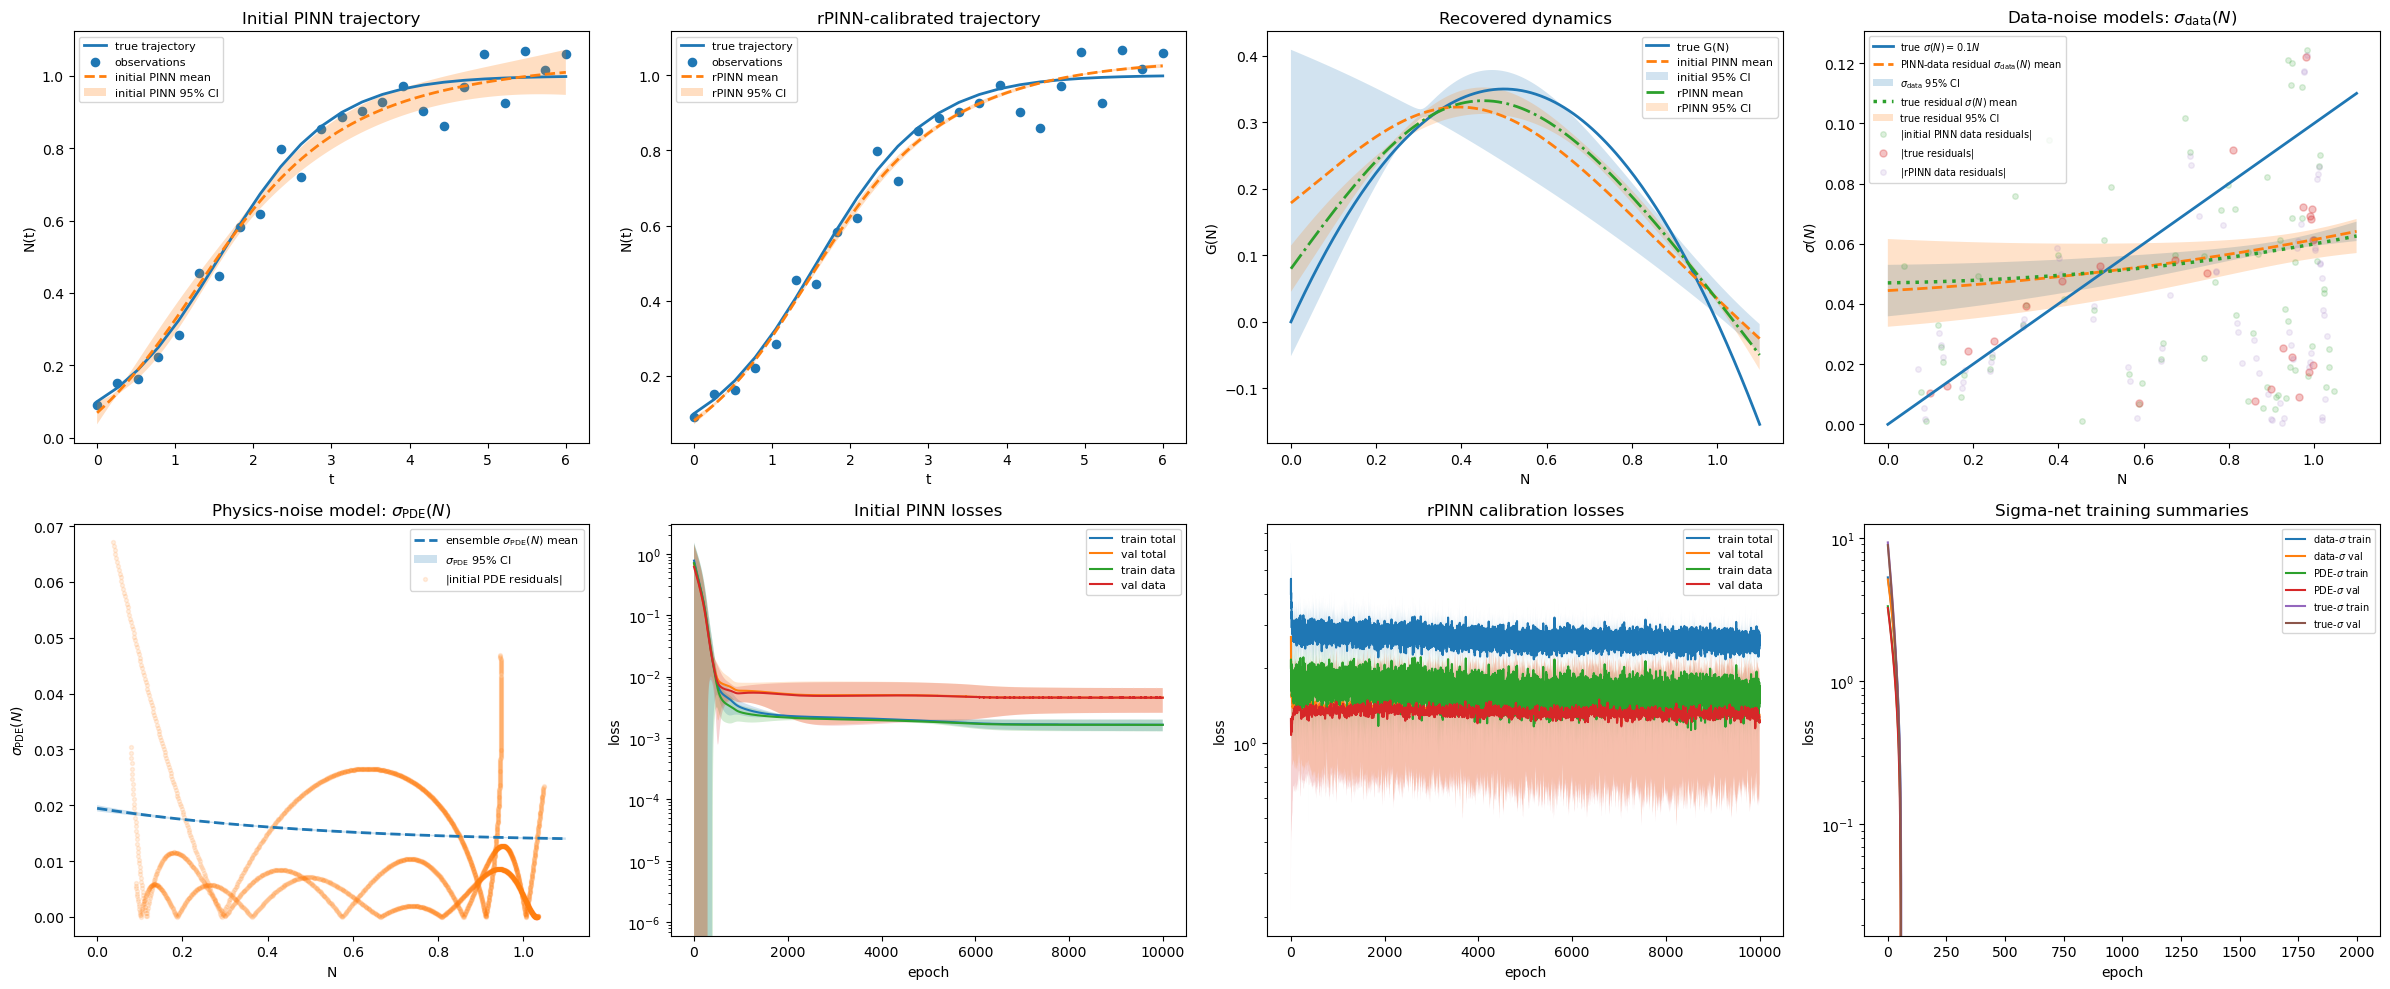

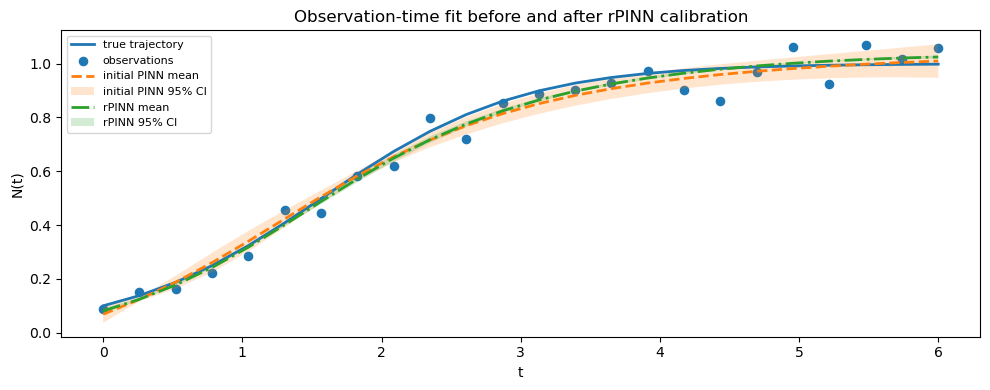


Initial PINN summary
--------------------
Number of PINN splits: 3
Mean best validation loss: 3.880476e-03
Std  best validation loss: 2.178569e-03
Mean best epoch: 4376.00
Std  best epoch: 4874.95

Data-residual sigma summary
---------------------------
Number of sigma repeats: 5
Mean best validation loss: -4.697219e+00
Std  best validation loss: 2.051518e-01
Mean best epoch: 1507.40
Std  best epoch: 626.87

True-residual sigma summary
---------------------------
Number of sigma repeats: 5
Mean best validation loss: -5.121099e+00
Std  best validation loss: 4.975691e-01
Mean best epoch: 1562.80
Std  best epoch: 600.34

PDE-residual sigma summary
--------------------------
Number of sigma repeats: 5
Mean best validation loss: -7.462228e+00
Std  best validation loss: 9.034729e-02
Mean best epoch: 1560.00
Std  best epoch: 471.22

rPINN calibration summary
-------------------------
Number of rPINN splits: 3
Mean best validation loss: 1.102474e+00
Std  best validation loss: 4.086936e-01
Mea

In [11]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
# ============================================================
r_true = 1.4
N0 = 0.1
numpts = 4 * (24 // 4)

t_obs = torch.linspace(0.0, 6.0, numpts, device=device).view(-1, 1)

def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# 2. Generate synthetic observed data
#    Noise law is heteroscedastic: sigma_true(N) = 0.1 N
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)

with torch.no_grad():
    y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
    y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)

torch.manual_seed(2)
y_data = y_true + 0.1 * torch.randn_like(y_true) * y_true

# evaluation grids
t_plot = torch.linspace(0.0, 6.0, 200, device=device).view(-1, 1)
N_grid = torch.linspace(0.0, 1.1, 200, device=device).view(-1, 1)

with torch.no_grad():
    G_grid_true = G_true(N_grid)
    sigma_true_grid = 0.1 * N_grid


# ============================================================
# 3. Model classes
# ============================================================
class SolutionNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, t):
        return self.net(t)


class DynamicsNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, N):
        return self.net(N)


class SigmaNet(nn.Module):
    def __init__(self, hidden_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
            nn.Softplus(),
        )

    def forward(self, N):
        return self.net(N) + 1e-4


# ============================================================
# 4. Helper functions
# ============================================================
def mean_and_ci(arr, ci=1.96):
    arr = np.array(arr)
    mean = arr.mean(axis=0)
    if arr.shape[0] == 1:
        lo = mean.copy()
        hi = mean.copy()
    else:
        sem = arr.std(axis=0, ddof=1) / np.sqrt(arr.shape[0])
        lo = mean - ci * sem
        hi = mean + ci * sem
    return mean, lo, hi

def gaussian_sigma_nll(resid, sigma):
    sigma2 = sigma ** 2
    return torch.mean(torch.log(sigma2) + (resid ** 2) / sigma2)

def sigma_monotonicity_loss(model, N_col):
    N_req = N_col.clone().detach().requires_grad_(True)
    sigma_col = model(N_req)
    dsigma_dN = torch.autograd.grad(
        outputs=sigma_col,
        inputs=N_req,
        grad_outputs=torch.ones_like(sigma_col),
        create_graph=True,
        retain_graph=True,
    )[0]
    return torch.sum(torch.relu(-dsigma_dN) ** 2)

def pinn_physics_residual(sol_net, dyn_net, t_col):
    N_pred_col = sol_net(t_col)
    dN_dt = torch.autograd.grad(
        outputs=N_pred_col,
        inputs=t_col,
        grad_outputs=torch.ones_like(N_pred_col),
        create_graph=True,
        retain_graph=True,
    )[0]
    rhs_pred = dyn_net(N_pred_col)
    phys_res = dN_dt - rhs_pred
    return N_pred_col, dN_dt, rhs_pred, phys_res

def predict_sigma_ensemble(models, N_in):
    vals = []
    with torch.no_grad():
        for m in models:
            vals.append(m(N_in).detach())
    return torch.stack(vals, dim=0).mean(dim=0)

def fit_sigma_repeated(
    N_all,
    resid_all,
    N_eval_grid,
    N_col_base,
    n_repeats=5,
    val_fraction=0.2,
    n_epochs=3000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=10.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="sigma",
):
    n_samples = N_all.shape[0]
    n_val = int(round(val_fraction * n_samples))
    n_val = max(1, min(n_val, n_samples - 1))
    n_train = n_samples - n_val

    train_total_histories = []
    train_nll_histories = []
    train_mon_histories = []

    val_total_histories = []
    val_nll_histories = []
    val_mon_histories = []

    curve_histories = []
    best_val_losses = []
    best_epochs = []
    best_models = []

    for repeat in range(n_repeats):
        g = torch.Generator(device=device)
        g.manual_seed(seed_offset_split + repeat)

        perm = torch.randperm(n_samples, generator=g, device=device)
        train_idx = perm[:n_train].sort().values
        val_idx = perm[n_train:].sort().values

        N_train = N_all[train_idx]
        r_train = resid_all[train_idx]
        N_val = N_all[val_idx]
        r_val = resid_all[val_idx]

        torch.manual_seed(seed_offset_model + repeat)
        np.random.seed(seed_offset_model + repeat)

        sigma_net = SigmaNet(hidden_dim=hidden_dim).to(device)
        opt = torch.optim.Adam(sigma_net.parameters(), lr=lr)

        train_total_history = []
        train_nll_history = []
        train_mon_history = []

        val_total_history = []
        val_nll_history = []
        val_mon_history = []

        best_val_loss = float("inf")
        best_epoch = -1
        best_state = None

        for epoch in range(n_epochs):
            opt.zero_grad()

            sigma_pred_train = sigma_net(N_train)
            train_nll = gaussian_sigma_nll(r_train, sigma_pred_train)
            train_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
            reg = lambda_reg * sum((p ** 2).sum() for p in sigma_net.parameters())

            train_total = train_nll + lambda_mon * train_mon + reg
            train_total.backward()
            opt.step()

            with torch.no_grad():
                sigma_pred_val = sigma_net(N_val)
                val_nll = gaussian_sigma_nll(r_val, sigma_pred_val)

            val_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
            val_total = val_nll + lambda_mon * val_mon

            train_total_history.append(train_total.item())
            train_nll_history.append(train_nll.item())
            train_mon_history.append(train_mon.item())

            val_total_history.append(val_total.item())
            val_nll_history.append(val_nll.item())
            val_mon_history.append(val_mon.item())

            if val_total.item() < best_val_loss:
                best_val_loss = val_total.item()
                best_epoch = epoch
                best_state = copy.deepcopy(sigma_net.state_dict())

        sigma_net.load_state_dict(best_state)
        sigma_net.eval()

        with torch.no_grad():
            sigma_curve = sigma_net(N_eval_grid).squeeze(1).cpu().numpy()

        best_models.append(copy.deepcopy(sigma_net))
        train_total_histories.append(train_total_history)
        train_nll_histories.append(train_nll_history)
        train_mon_histories.append(train_mon_history)

        val_total_histories.append(val_total_history)
        val_nll_histories.append(val_nll_history)
        val_mon_histories.append(val_mon_history)

        curve_histories.append(sigma_curve)
        best_val_losses.append(best_val_loss)
        best_epochs.append(best_epoch)

        print(
            f"{label} repeat {repeat + 1:2d}/{n_repeats} done | "
            f"Best epoch = {best_epoch:4d} | Best val loss = {best_val_loss:.6e}"
        )

    return {
        "train_total_histories": np.array(train_total_histories),
        "train_nll_histories": np.array(train_nll_histories),
        "train_mon_histories": np.array(train_mon_histories),
        "val_total_histories": np.array(val_total_histories),
        "val_nll_histories": np.array(val_nll_histories),
        "val_mon_histories": np.array(val_mon_histories),
        "curve_histories": np.array(curve_histories),
        "best_val_losses": np.array(best_val_losses),
        "best_epochs": np.array(best_epochs),
        "best_models": best_models,
    }


# ============================================================
# 5. Initial PINN fit across train/validation splits
# ============================================================
n_col = 1000
t_col_base = torch.linspace(0.0, 6.0, n_col, device=device).view(-1, 1)

n_epochs = 10000
n_splits = 3

val_fraction = 0.2
n_obs = t_obs.shape[0]
n_val = int(round(val_fraction * n_obs))
n_train = n_obs - n_val

lambda_phys = 1.0
lambda_ic = 0.0

learning_rate = 1e-3
hidden_dim_sol = 4
hidden_dim_dyn = 4

train_total_histories = []
train_data_histories = []
train_phys_histories = []

val_total_histories = []
val_data_histories = []
val_phys_histories = []

traj_histories = []
rhs_histories = []
obs_fit_histories = []

best_val_losses = []
best_epochs = []

best_initial_states = []

# extra storage for PDE residual uncertainty estimation
pde_sigma_N_histories = []
pde_sigma_resid_histories = []

for split in range(n_splits):
    g = torch.Generator(device=device)
    g.manual_seed(1000 + split)

    perm = torch.randperm(n_obs, generator=g, device=device)
    train_idx = perm[:n_train].sort().values
    val_idx = perm[n_train:].sort().values

    t_train = t_obs[train_idx]
    y_train = y_data[train_idx]

    t_val = t_obs[val_idx]
    y_val = y_data[val_idx]

    torch.manual_seed(1234 + split)
    np.random.seed(1234 + split)

    sol_net = SolutionNet(hidden_dim=hidden_dim_sol).to(device)
    dyn_net = DynamicsNet(hidden_dim=hidden_dim_dyn).to(device)

    optimizer = torch.optim.Adam(
        list(sol_net.parameters()) + list(dyn_net.parameters()),
        lr=learning_rate
    )

    train_total_history = []
    train_data_history = []
    train_phys_history = []

    val_total_history = []
    val_data_history = []
    val_phys_history = []

    best_val_loss = float("inf")
    best_epoch = -1
    best_state = None

    for epoch in range(n_epochs):
        optimizer.zero_grad()

        N_pred_train = sol_net(t_train)
        train_data_loss = torch.mean((N_pred_train - y_train) ** 2)

        t_col = t_col_base.clone().detach().requires_grad_(True)
        _, _, _, phys_res = pinn_physics_residual(sol_net, dyn_net, t_col)
        phys_loss = torch.mean(phys_res ** 2)

        t0 = torch.zeros((1, 1), device=device)
        N0_pred = sol_net(t0)
        ic_loss = torch.mean(
            (N0_pred - torch.tensor([[N0]], dtype=torch.float32, device=device)) ** 2
        )

        train_loss = train_data_loss + lambda_phys * phys_loss + lambda_ic * ic_loss
        train_loss.backward()
        optimizer.step()

        with torch.no_grad():
            N_pred_val = sol_net(t_val)
            val_data_loss = torch.mean((N_pred_val - y_val) ** 2)

        t_col_val = t_col_base.clone().detach().requires_grad_(True)
        _, _, _, val_phys_res = pinn_physics_residual(sol_net, dyn_net, t_col_val)
        val_phys_loss = torch.mean(val_phys_res ** 2)
        val_loss = val_data_loss + lambda_phys * val_phys_loss

        train_total_history.append(train_loss.item())
        train_data_history.append(train_data_loss.item())
        train_phys_history.append(phys_loss.item())

        val_total_history.append(val_loss.item())
        val_data_history.append(val_data_loss.item())
        val_phys_history.append(val_phys_loss.item())

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_epoch = epoch
            best_state = {
                "sol_net": copy.deepcopy(sol_net.state_dict()),
                "dyn_net": copy.deepcopy(dyn_net.state_dict()),
            }

    print(
        f"Initial PINN split {split + 1:2d}/{n_splits} done | "
        f"Best epoch = {best_epoch:5d} | Best val loss = {best_val_loss:.6e}"
    )

    sol_net.load_state_dict(best_state["sol_net"])
    dyn_net.load_state_dict(best_state["dyn_net"])
    sol_net.eval()
    dyn_net.eval()

    with torch.no_grad():
        N_pinn = sol_net(t_plot)
        G_grid_learned = dyn_net(N_grid)
        N_fit_obs = sol_net(t_obs)

    # PDE residual dataset from first-stage PINN on collocation grid
    t_col_eval = t_col_base.clone().detach().requires_grad_(True)
    N_pred_col_eval, _, _, phys_res_eval = pinn_physics_residual(sol_net, dyn_net, t_col_eval)

    with torch.no_grad():
        pde_sigma_N_histories.append(N_pred_col_eval.detach().cpu().numpy().reshape(-1, 1))
        pde_sigma_resid_histories.append(phys_res_eval.detach().cpu().numpy().reshape(-1, 1))

    train_total_histories.append(train_total_history)
    train_data_histories.append(train_data_history)
    train_phys_histories.append(train_phys_history)

    val_total_histories.append(val_total_history)
    val_data_histories.append(val_data_history)
    val_phys_histories.append(val_phys_history)

    traj_histories.append(N_pinn.squeeze(1).cpu().numpy())
    rhs_histories.append(G_grid_learned.squeeze(1).cpu().numpy())
    obs_fit_histories.append(N_fit_obs.squeeze(1).cpu().numpy())

    best_val_losses.append(best_val_loss)
    best_epochs.append(best_epoch)

    best_initial_states.append({
        "sol_net": copy.deepcopy(sol_net.state_dict()),
        "dyn_net": copy.deepcopy(dyn_net.state_dict()),
        "train_idx": train_idx.clone(),
        "val_idx": val_idx.clone(),
    })

train_total_histories = np.array(train_total_histories)
train_data_histories = np.array(train_data_histories)
train_phys_histories = np.array(train_phys_histories)

val_total_histories = np.array(val_total_histories)
val_data_histories = np.array(val_data_histories)
val_phys_histories = np.array(val_phys_histories)

traj_histories = np.array(traj_histories)
rhs_histories = np.array(rhs_histories)
obs_fit_histories = np.array(obs_fit_histories)

traj_mean, traj_lo, traj_hi = mean_and_ci(traj_histories)
rhs_mean, rhs_lo, rhs_hi = mean_and_ci(rhs_histories)
obs_fit_mean, obs_fit_lo, obs_fit_hi = mean_and_ci(obs_fit_histories)


# ============================================================
# 6. Learn sigma_data(N) from PINN data residuals using 5 repeats
#    residual_data = y_data - N_hat_PINN
# ============================================================
with torch.no_grad():
    y_rep = y_data.squeeze(1).cpu().numpy()[None, :]
    resid_pinn_all_np = y_rep - obs_fit_histories

    N_pinn_sigma_all_np = obs_fit_histories.reshape(-1, 1)
    resid_pinn_sigma_all_np = resid_pinn_all_np.reshape(-1, 1)

    mask = N_pinn_sigma_all_np.squeeze() > 0.0
    N_pinn_sigma_all_np = N_pinn_sigma_all_np[mask]
    resid_pinn_sigma_all_np = resid_pinn_sigma_all_np[mask]

N_pinn_sigma_all = torch.tensor(N_pinn_sigma_all_np, dtype=torch.float32, device=device)
resid_pinn_sigma_all = torch.tensor(resid_pinn_sigma_all_np, dtype=torch.float32, device=device)

N_sigma_data_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_pinn_sigma_all.max().item())),
    200,
    device=device
).view(-1, 1)

sigma_data_results = fit_sigma_repeated(
    N_all=N_pinn_sigma_all,
    resid_all=resid_pinn_sigma_all,
    N_eval_grid=N_grid,
    N_col_base=N_sigma_data_col_base,
    n_repeats=5,
    val_fraction=0.2,
    n_epochs=2000,
    lr=1e-3,
    hidden_dim=8,
    lambda_mon=10.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="DATA-sigma",
)

sigma_data_mean, sigma_data_lo, sigma_data_hi = mean_and_ci(sigma_data_results["curve_histories"])
sigma_data_models = sigma_data_results["best_models"]


# ============================================================
# 7. Learn sigma_truefit(N) from true residuals using 5 repeats
#    residual_true = y_data - y_true
#    This is only for comparison / plotting
# ============================================================
with torch.no_grad():
    N_true_sigma_np = y_true.squeeze(1).cpu().numpy().reshape(-1, 1)
    resid_true_sigma_np = (y_data - y_true).squeeze(1).cpu().numpy().reshape(-1, 1)

    mask_true = N_true_sigma_np.squeeze() > 0.0
    N_true_sigma_np = N_true_sigma_np[mask_true]
    resid_true_sigma_np = resid_true_sigma_np[mask_true]

N_true_sigma = torch.tensor(N_true_sigma_np, dtype=torch.float32, device=device)
resid_true_sigma = torch.tensor(resid_true_sigma_np, dtype=torch.float32, device=device)

N_true_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_true_sigma.max().item())),
    200,
    device=device
).view(-1, 1)

sigma_truefit_results = fit_sigma_repeated(
    N_all=N_true_sigma,
    resid_all=resid_true_sigma,
    N_eval_grid=N_grid,
    N_col_base=N_true_sigma_col_base,
    n_repeats=5,
    val_fraction=0.2,
    n_epochs=2000,
    lr=1e-3,
    hidden_dim=8,
    lambda_mon=10.0,
    lambda_reg=1e-5,
    seed_offset_split=9000,
    seed_offset_model=11000,
    label="TRUE-sigma",
)

sigma_truefit_mean, sigma_truefit_lo, sigma_truefit_hi = mean_and_ci(
    sigma_truefit_results["curve_histories"]
)


# ============================================================
# 8. Learn sigma_PDE(N) from first-stage PDE residuals using 5 repeats
#    residual_pde = dN_hat/dt - G_hat(N_hat)
# ============================================================
with torch.no_grad():
    N_pde_sigma_all_np = np.concatenate(pde_sigma_N_histories, axis=0)
    resid_pde_sigma_all_np = np.concatenate(pde_sigma_resid_histories, axis=0)

    mask_pde = N_pde_sigma_all_np.squeeze() > 0.0
    N_pde_sigma_all_np = N_pde_sigma_all_np[mask_pde]
    resid_pde_sigma_all_np = resid_pde_sigma_all_np[mask_pde]

N_pde_sigma_all = torch.tensor(N_pde_sigma_all_np, dtype=torch.float32, device=device)
resid_pde_sigma_all = torch.tensor(resid_pde_sigma_all_np, dtype=torch.float32, device=device)

N_sigma_pde_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_pde_sigma_all.max().item())),
    200,
    device=device
).view(-1, 1)

sigma_pde_results = fit_sigma_repeated(
    N_all=N_pde_sigma_all,
    resid_all=resid_pde_sigma_all,
    N_eval_grid=N_grid,
    N_col_base=N_sigma_pde_col_base,
    n_repeats=5,
    val_fraction=0.2,
    n_epochs=2000,
    lr=1e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=13000,
    seed_offset_model=15000,
    label="PDE-sigma",
)

sigma_pde_mean, sigma_pde_lo, sigma_pde_hi = mean_and_ci(sigma_pde_results["curve_histories"])
sigma_pde_models = sigma_pde_results["best_models"]


# ============================================================
# 9. rPINN calibration stage
#    Uses sigma_data ensemble for data term
#    Uses sigma_PDE ensemble for PDE term
# ============================================================
rPINN_epochs = 10000
rPINN_lr = 1e-3
rPINN_lambda_phys = 1.0
rPINN_lambda_ic = 0.0
rPINN_num_noise_realizations = 4
rPINN_phys_scale = 1.0
rPINN_data_scale = 1.0

rtrain_total_histories = []
rtrain_data_histories = []
rtrain_phys_histories = []

rval_total_histories = []
rval_data_histories = []
rval_phys_histories = []

rtraj_histories = []
rrhs_histories = []
robs_fit_histories = []

rbest_val_losses = []
rbest_epochs = []

for split in range(n_splits):
    train_idx = best_initial_states[split]["train_idx"]
    val_idx = best_initial_states[split]["val_idx"]

    t_train = t_obs[train_idx]
    y_train = y_data[train_idx]

    t_val = t_obs[val_idx]
    y_val = y_data[val_idx]

    torch.manual_seed(20000 + split)
    np.random.seed(20000 + split)

    sol_net = SolutionNet(hidden_dim=hidden_dim_sol).to(device)
    dyn_net = DynamicsNet(hidden_dim=hidden_dim_dyn).to(device)
    sol_net.load_state_dict(best_initial_states[split]["sol_net"])
    dyn_net.load_state_dict(best_initial_states[split]["dyn_net"])

    optimizer = torch.optim.Adam(
        list(sol_net.parameters()) + list(dyn_net.parameters()),
        lr=rPINN_lr
    )

    rtrain_total_history = []
    rtrain_data_history = []
    rtrain_phys_history = []

    rval_total_history = []
    rval_data_history = []
    rval_phys_history = []

    best_val_loss = float("inf")
    best_epoch = -1
    best_state = None

    for epoch in range(rPINN_epochs):
        optimizer.zero_grad()

        # current train-point state and data sigma ensemble
        with torch.no_grad():
            N_anchor_train = sol_net(t_train)
            sigma_data_train = predict_sigma_ensemble(
                sigma_data_models,
                torch.clamp(N_anchor_train, min=0.0, max=1.5)
            )
            sigma_data_train = torch.clamp(sigma_data_train, min=1e-4)

        # collocation physics residual and PDE sigma ensemble
        t_col = t_col_base.clone().detach().requires_grad_(True)
        N_pred_col, _, _, phys_res = pinn_physics_residual(sol_net, dyn_net, t_col)

        with torch.no_grad():
            sigma_pde_col = predict_sigma_ensemble(
                sigma_pde_models,
                torch.clamp(N_pred_col.detach(), min=0.0, max=1.5)
            )
            sigma_pde_col = torch.clamp(sigma_pde_col, min=1e-4)

        N_pred_train = sol_net(t_train)

        data_loss_mc = 0.0
        phys_loss_mc = 0.0

        for _ in range(rPINN_num_noise_realizations):
            eps_d = torch.randn_like(y_train)
            eps_p = torch.randn_like(phys_res)

            y_noisy = y_train + rPINN_data_scale * sigma_data_train * eps_d
            pde_noise_target = rPINN_phys_scale * sigma_pde_col * eps_p

            data_loss_mc = data_loss_mc + torch.mean(
                ((N_pred_train - y_noisy) / sigma_data_train) ** 2
            )
            phys_loss_mc = phys_loss_mc + torch.mean(
                ((phys_res - pde_noise_target) / sigma_pde_col) ** 2
            )

        data_loss_mc = data_loss_mc / rPINN_num_noise_realizations
        phys_loss_mc = phys_loss_mc / rPINN_num_noise_realizations

        t0 = torch.zeros((1, 1), device=device)
        N0_pred = sol_net(t0)
        ic_loss = torch.mean(
            (N0_pred - torch.tensor([[N0]], dtype=torch.float32, device=device)) ** 2
        )

        train_loss = data_loss_mc + rPINN_lambda_phys * phys_loss_mc + rPINN_lambda_ic * ic_loss
        train_loss.backward()
        optimizer.step()

        # validation
        with torch.no_grad():
            N_pred_val = sol_net(t_val)
            sigma_data_val = predict_sigma_ensemble(
                sigma_data_models,
                torch.clamp(N_pred_val, min=0.0, max=1.5)
            )
            sigma_data_val = torch.clamp(sigma_data_val, min=1e-4)
            val_data_loss = torch.mean(((N_pred_val - y_val) / sigma_data_val) ** 2)

        t_col_val = t_col_base.clone().detach().requires_grad_(True)
        N_pred_col_val, _, _, phys_res_val = pinn_physics_residual(sol_net, dyn_net, t_col_val)

        with torch.no_grad():
            sigma_pde_val = predict_sigma_ensemble(
                sigma_pde_models,
                torch.clamp(N_pred_col_val.detach(), min=0.0, max=1.5)
            )
            sigma_pde_val = torch.clamp(sigma_pde_val, min=1e-4)

        val_phys_loss = torch.mean((phys_res_val / sigma_pde_val) ** 2)
        val_loss = val_data_loss + rPINN_lambda_phys * val_phys_loss

        rtrain_total_history.append(train_loss.item())
        rtrain_data_history.append(data_loss_mc.item())
        rtrain_phys_history.append(phys_loss_mc.item())

        rval_total_history.append(val_loss.item())
        rval_data_history.append(val_data_loss.item())
        rval_phys_history.append(val_phys_loss.item())

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_epoch = epoch
            best_state = {
                "sol_net": copy.deepcopy(sol_net.state_dict()),
                "dyn_net": copy.deepcopy(dyn_net.state_dict()),
            }

    print(
        f"rPINN calibration split {split + 1:2d}/{n_splits} done | "
        f"Best epoch = {best_epoch:5d} | Best val loss = {best_val_loss:.6e}"
    )

    sol_net.load_state_dict(best_state["sol_net"])
    dyn_net.load_state_dict(best_state["dyn_net"])
    sol_net.eval()
    dyn_net.eval()

    with torch.no_grad():
        N_rpinn = sol_net(t_plot)
        G_grid_rlearned = dyn_net(N_grid)
        N_rfit_obs = sol_net(t_obs)

    rtrain_total_histories.append(rtrain_total_history)
    rtrain_data_histories.append(rtrain_data_history)
    rtrain_phys_histories.append(rtrain_phys_history)

    rval_total_histories.append(rval_total_history)
    rval_data_histories.append(rval_data_history)
    rval_phys_histories.append(rval_phys_history)

    rtraj_histories.append(N_rpinn.squeeze(1).cpu().numpy())
    rrhs_histories.append(G_grid_rlearned.squeeze(1).cpu().numpy())
    robs_fit_histories.append(N_rfit_obs.squeeze(1).cpu().numpy())

    rbest_val_losses.append(best_val_loss)
    rbest_epochs.append(best_epoch)

rtrain_total_histories = np.array(rtrain_total_histories)
rtrain_data_histories = np.array(rtrain_data_histories)
rtrain_phys_histories = np.array(rtrain_phys_histories)

rval_total_histories = np.array(rval_total_histories)
rval_data_histories = np.array(rval_data_histories)
rval_phys_histories = np.array(rval_phys_histories)

rtraj_histories = np.array(rtraj_histories)
rrhs_histories = np.array(rrhs_histories)
robs_fit_histories = np.array(robs_fit_histories)

rtraj_mean, rtraj_lo, rtraj_hi = mean_and_ci(rtraj_histories)
rrhs_mean, rrhs_lo, rrhs_hi = mean_and_ci(rrhs_histories)
robs_fit_mean, robs_fit_lo, robs_fit_hi = mean_and_ci(robs_fit_histories)


# ============================================================
# 10. Post-calibration residual checks
# ============================================================
with torch.no_grad():
    resid_after_rpinn_np = y_data.squeeze(1).cpu().numpy()[None, :] - robs_fit_histories
    N_after_rpinn_np = robs_fit_histories.reshape(-1, 1)
    resid_after_rpinn_flat_np = resid_after_rpinn_np.reshape(-1, 1)

    mask = N_after_rpinn_np.squeeze() > 0.0
    N_after_rpinn_np = N_after_rpinn_np[mask]
    resid_after_rpinn_flat_np = resid_after_rpinn_flat_np[mask]



# rebuild rPINN models for post-check only
# (not saved above, so use best-state-free approximation by refitting trajectories already stored is not possible;
#  instead we skip storing full post-check PDE ensemble curves from final models.)

# ============================================================
# 11. Plots
# ============================================================
fig, axes = plt.subplots(2, 4, figsize=(24, 10))

# ------------------------------------------------------------
# Initial PINN trajectory
# ------------------------------------------------------------
axes[0, 0].plot(
    t_obs.cpu().numpy(),
    y_true.squeeze(1).cpu().numpy(),
    label="true trajectory",
    linewidth=2,
)
axes[0, 0].scatter(
    t_obs.cpu().numpy(),
    y_data.squeeze(1).cpu().numpy(),
    label="observations",
    s=35,
)
axes[0, 0].plot(
    t_plot.cpu().numpy(),
    traj_mean,
    "--",
    linewidth=2,
    label="initial PINN mean",
)
axes[0, 0].fill_between(
    t_plot.squeeze(1).cpu().numpy(),
    traj_lo,
    traj_hi,
    alpha=0.25,
    label="initial PINN 95% CI",
)
axes[0, 0].set_xlabel("t")
axes[0, 0].set_ylabel("N(t)")
axes[0, 0].set_title("Initial PINN trajectory")
axes[0, 0].legend(fontsize=8)

# ------------------------------------------------------------
# rPINN-calibrated trajectory
# ------------------------------------------------------------
axes[0, 1].plot(
    t_obs.cpu().numpy(),
    y_true.squeeze(1).cpu().numpy(),
    label="true trajectory",
    linewidth=2,
)
axes[0, 1].scatter(
    t_obs.cpu().numpy(),
    y_data.squeeze(1).cpu().numpy(),
    label="observations",
    s=35,
)
axes[0, 1].plot(
    t_plot.cpu().numpy(),
    rtraj_mean,
    "--",
    linewidth=2,
    label="rPINN mean",
)
axes[0, 1].fill_between(
    t_plot.squeeze(1).cpu().numpy(),
    rtraj_lo,
    rtraj_hi,
    alpha=0.25,
    label="rPINN 95% CI",
)
axes[0, 1].set_xlabel("t")
axes[0, 1].set_ylabel("N(t)")
axes[0, 1].set_title("rPINN-calibrated trajectory")
axes[0, 1].legend(fontsize=8)

# ------------------------------------------------------------
# Dynamics before / after calibration
# ------------------------------------------------------------
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    G_grid_true.squeeze(1).cpu().numpy(),
    label="true G(N)",
    linewidth=2,
)
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    rhs_mean,
    "--",
    linewidth=2,
    label="initial PINN mean",
)
axes[0, 2].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    rhs_lo,
    rhs_hi,
    alpha=0.20,
    label="initial 95% CI",
)
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    rrhs_mean,
    "-.",
    linewidth=2,
    label="rPINN mean",
)
axes[0, 2].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    rrhs_lo,
    rrhs_hi,
    alpha=0.20,
    label="rPINN 95% CI",
)
axes[0, 2].set_xlabel("N")
axes[0, 2].set_ylabel("G(N)")
axes[0, 2].set_title("Recovered dynamics")
axes[0, 2].legend(fontsize=8)

# ------------------------------------------------------------
# sigma_data(N) compared with sigma_truefit(N)
# ------------------------------------------------------------
axes[0, 3].plot(
    N_grid.cpu().numpy(),
    sigma_true_grid.squeeze(1).cpu().numpy(),
    linewidth=2,
    label=r"true $\sigma(N)=0.1N$",
)
axes[0, 3].plot(
    N_grid.cpu().numpy(),
    sigma_data_mean,
    "--",
    linewidth=2,
    label=r"PINN-data residual $\sigma_{\mathrm{data}}(N)$ mean",
)
axes[0, 3].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_data_lo,
    sigma_data_hi,
    alpha=0.22,
    label=r"$\sigma_{\mathrm{data}}$ 95% CI",
)
axes[0, 3].plot(
    N_grid.cpu().numpy(),
    sigma_truefit_mean,
    ":",
    linewidth=2.5,
    label=r"true residual $\sigma(N)$ mean",
)
axes[0, 3].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_truefit_lo,
    sigma_truefit_hi,
    alpha=0.22,
    label="true residual 95% CI",
)
axes[0, 3].scatter(
    N_pinn_sigma_all.cpu().numpy().squeeze(),
    np.abs(resid_pinn_sigma_all.cpu().numpy().squeeze()),
    s=16,
    alpha=0.16,
    label=r"$|$initial PINN data residuals$|$",
)
axes[0, 3].scatter(
    N_true_sigma.cpu().numpy().squeeze(),
    np.abs(resid_true_sigma.cpu().numpy().squeeze()),
    s=26,
    alpha=0.28,
    label=r"$|$true residuals$|$",
)
axes[0, 3].scatter(
    N_after_rpinn_np.squeeze(),
    np.abs(resid_after_rpinn_flat_np.squeeze()),
    s=16,
    alpha=0.12,
    label=r"$|$rPINN data residuals$|$",
)
axes[0, 3].set_xlabel("N")
axes[0, 3].set_ylabel(r"$\sigma(N)$")
axes[0, 3].set_title(r"Data-noise models: $\sigma_{\mathrm{data}}(N)$")
axes[0, 3].legend(fontsize=7)

# ------------------------------------------------------------
# sigma_PDE(N)
# ------------------------------------------------------------
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_pde_mean,
    "--",
    linewidth=2,
    label=r"ensemble $\sigma_{\mathrm{PDE}}(N)$ mean",
)
axes[1, 0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_pde_lo,
    sigma_pde_hi,
    alpha=0.22,
    label=r"$\sigma_{\mathrm{PDE}}$ 95% CI",
)
axes[1, 0].scatter(
    N_pde_sigma_all.cpu().numpy().squeeze(),
    np.abs(resid_pde_sigma_all.cpu().numpy().squeeze()),
    s=8,
    alpha=0.12,
    label=r"$|$initial PDE residuals$|$",
)
axes[1, 0].set_xlabel("N")
axes[1, 0].set_ylabel(r"$\sigma_{\mathrm{PDE}}(N)$")
axes[1, 0].set_title(r"Physics-noise model: $\sigma_{\mathrm{PDE}}(N)$")
axes[1, 0].legend(fontsize=8)

# ------------------------------------------------------------
# Initial PINN losses
# ------------------------------------------------------------
epochs_init = np.arange(n_epochs)
train_total_mean, train_total_lo, train_total_hi = mean_and_ci(train_total_histories)
val_total_mean, val_total_lo, val_total_hi = mean_and_ci(val_total_histories)
train_data_mean, train_data_lo, train_data_hi = mean_and_ci(train_data_histories)
val_data_mean, val_data_lo, val_data_hi = mean_and_ci(val_data_histories)

axes[1, 1].plot(epochs_init, train_total_mean, label="train total")
axes[1, 1].fill_between(epochs_init, train_total_lo, train_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, val_total_mean, label="val total")
axes[1, 1].fill_between(epochs_init, val_total_lo, val_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, train_data_mean, label="train data")
axes[1, 1].fill_between(epochs_init, train_data_lo, train_data_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, val_data_mean, label="val data")
axes[1, 1].fill_between(epochs_init, val_data_lo, val_data_hi, alpha=0.2)
axes[1, 1].set_yscale("log")
axes[1, 1].set_xlabel("epoch")
axes[1, 1].set_ylabel("loss")
axes[1, 1].set_title("Initial PINN losses")
axes[1, 1].legend(fontsize=8)

# ------------------------------------------------------------
# rPINN losses
# ------------------------------------------------------------
epochs_r = np.arange(rPINN_epochs)
rtrain_total_mean, rtrain_total_lo, rtrain_total_hi = mean_and_ci(rtrain_total_histories)
rval_total_mean, rval_total_lo, rval_total_hi = mean_and_ci(rval_total_histories)
rtrain_data_mean, rtrain_data_lo, rtrain_data_hi = mean_and_ci(rtrain_data_histories)
rval_data_mean, rval_data_lo, rval_data_hi = mean_and_ci(rval_data_histories)

axes[1, 2].plot(epochs_r, rtrain_total_mean, label="train total")
axes[1, 2].fill_between(epochs_r, rtrain_total_lo, rtrain_total_hi, alpha=0.2)
axes[1, 2].plot(epochs_r, rval_total_mean, label="val total")
axes[1, 2].fill_between(epochs_r, rval_total_lo, rval_total_hi, alpha=0.2)
axes[1, 2].plot(epochs_r, rtrain_data_mean, label="train data")
axes[1, 2].fill_between(epochs_r, rtrain_data_lo, rtrain_data_hi, alpha=0.2)
axes[1, 2].plot(epochs_r, rval_data_mean, label="val data")
axes[1, 2].fill_between(epochs_r, rval_data_lo, rval_data_hi, alpha=0.2)
axes[1, 2].set_yscale("log")
axes[1, 2].set_xlabel("epoch")
axes[1, 2].set_ylabel("loss")
axes[1, 2].set_title("rPINN calibration losses")
axes[1, 2].legend(fontsize=8)

# ------------------------------------------------------------
# sigma training losses (summary plot)
# ------------------------------------------------------------
sigma_epochs = np.arange(sigma_data_results["train_total_histories"].shape[1])

sigma_data_train_mean, _, _ = mean_and_ci(sigma_data_results["train_total_histories"])
sigma_data_val_mean, _, _ = mean_and_ci(sigma_data_results["val_total_histories"])

sigma_pde_train_mean, _, _ = mean_and_ci(sigma_pde_results["train_total_histories"])
sigma_pde_val_mean, _, _ = mean_and_ci(sigma_pde_results["val_total_histories"])

sigma_true_train_mean, _, _ = mean_and_ci(sigma_truefit_results["train_total_histories"])
sigma_true_val_mean, _, _ = mean_and_ci(sigma_truefit_results["val_total_histories"])

axes[1, 3].plot(sigma_epochs, sigma_data_train_mean, label=r"data-$\sigma$ train")
axes[1, 3].plot(sigma_epochs, sigma_data_val_mean, label=r"data-$\sigma$ val")
axes[1, 3].plot(sigma_epochs, sigma_pde_train_mean, label=r"PDE-$\sigma$ train")
axes[1, 3].plot(sigma_epochs, sigma_pde_val_mean, label=r"PDE-$\sigma$ val")
axes[1, 3].plot(sigma_epochs, sigma_true_train_mean, label=r"true-$\sigma$ train")
axes[1, 3].plot(sigma_epochs, sigma_true_val_mean, label=r"true-$\sigma$ val")
axes[1, 3].set_yscale("log")
axes[1, 3].set_xlabel("epoch")
axes[1, 3].set_ylabel("loss")
axes[1, 3].set_title("Sigma-net training summaries")
axes[1, 3].legend(fontsize=7)

plt.tight_layout()
plt.show()


# ============================================================
# 12. Observation-time comparison
# ============================================================
plt.figure(figsize=(10, 4))
plt.plot(
    t_obs.cpu().numpy(),
    y_true.squeeze(1).cpu().numpy(),
    label="true trajectory",
    linewidth=2,
)
plt.scatter(
    t_obs.cpu().numpy(),
    y_data.squeeze(1).cpu().numpy(),
    label="observations",
    s=35,
)
plt.plot(
    t_obs.cpu().numpy(),
    obs_fit_mean,
    "--",
    linewidth=2,
    label="initial PINN mean",
)
plt.fill_between(
    t_obs.squeeze(1).cpu().numpy(),
    obs_fit_lo,
    obs_fit_hi,
    alpha=0.20,
    label="initial PINN 95% CI",
)
plt.plot(
    t_obs.cpu().numpy(),
    robs_fit_mean,
    "-.",
    linewidth=2,
    label="rPINN mean",
)
plt.fill_between(
    t_obs.squeeze(1).cpu().numpy(),
    robs_fit_lo,
    robs_fit_hi,
    alpha=0.20,
    label="rPINN 95% CI",
)
plt.xlabel("t")
plt.ylabel("N(t)")
plt.title("Observation-time fit before and after rPINN calibration")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# 13. Summary
# ============================================================
print("\nInitial PINN summary")
print("--------------------")
print(f"Number of PINN splits: {n_splits}")
print(f"Mean best validation loss: {np.mean(best_val_losses):.6e}")
print(f"Std  best validation loss: {np.std(best_val_losses, ddof=1):.6e}")
print(f"Mean best epoch: {np.mean(best_epochs):.2f}")
print(f"Std  best epoch: {np.std(best_epochs, ddof=1):.2f}")

print("\nData-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_data_results['best_val_losses'])}")
print(f"Mean best validation loss: {sigma_data_results['best_val_losses'].mean():.6e}")
print(f"Std  best validation loss: {sigma_data_results['best_val_losses'].std(ddof=1):.6e}")
print(f"Mean best epoch: {sigma_data_results['best_epochs'].mean():.2f}")
print(f"Std  best epoch: {sigma_data_results['best_epochs'].std(ddof=1):.2f}")

print("\nTrue-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_truefit_results['best_val_losses'])}")
print(f"Mean best validation loss: {sigma_truefit_results['best_val_losses'].mean():.6e}")
print(f"Std  best validation loss: {sigma_truefit_results['best_val_losses'].std(ddof=1):.6e}")
print(f"Mean best epoch: {sigma_truefit_results['best_epochs'].mean():.2f}")
print(f"Std  best epoch: {sigma_truefit_results['best_epochs'].std(ddof=1):.2f}")

print("\nPDE-residual sigma summary")
print("--------------------------")
print(f"Number of sigma repeats: {len(sigma_pde_results['best_val_losses'])}")
print(f"Mean best validation loss: {sigma_pde_results['best_val_losses'].mean():.6e}")
print(f"Std  best validation loss: {sigma_pde_results['best_val_losses'].std(ddof=1):.6e}")
print(f"Mean best epoch: {sigma_pde_results['best_epochs'].mean():.2f}")
print(f"Std  best epoch: {sigma_pde_results['best_epochs'].std(ddof=1):.2f}")

print("\nrPINN calibration summary")
print("-------------------------")
print(f"Number of rPINN splits: {n_splits}")
print(f"Mean best validation loss: {np.mean(rbest_val_losses):.6e}")
print(f"Std  best validation loss: {np.std(rbest_val_losses, ddof=1):.6e}")
print(f"Mean best epoch: {np.mean(rbest_epochs):.2f}")
print(f"Std  best epoch: {np.std(rbest_epochs, ddof=1):.2f}")

print("\nObserved time points: initial PINN mean vs rPINN mean")
for ti, yt, yd, mu0, mu1 in zip(
    t_obs.squeeze(1).cpu().numpy(),
    y_true.squeeze(1).cpu().numpy(),
    y_data.squeeze(1).cpu().numpy(),
    obs_fit_mean,
    robs_fit_mean,
):
    print(
        f"t = {ti:6.3f} | true = {yt:8.5f} | data = {yd:8.5f} | "
        f"PINN = {mu0:8.5f} | rPINN = {mu1:8.5f}"
    )

Initial PINN split  1/3 done | Best epoch =  9859 | Best val loss = 6.389331e-03
Initial PINN split  2/3 done | Best epoch =   531 | Best val loss = 2.785424e-03
Initial PINN split  3/3 done | Best epoch =  2738 | Best val loss = 2.466674e-03
DATA-sigma repeat  1/5 done | Best epoch = 1999 | Best val loss = -4.567615e+00
DATA-sigma repeat  2/5 done | Best epoch = 1999 | Best val loss = -4.483912e+00
DATA-sigma repeat  3/5 done | Best epoch =  992 | Best val loss = -4.844696e+00
DATA-sigma repeat  4/5 done | Best epoch = 1999 | Best val loss = -4.970455e+00
DATA-sigma repeat  5/5 done | Best epoch =  697 | Best val loss = -4.594549e+00
TRUE-sigma repeat  1/5 done | Best epoch = 1999 | Best val loss = -5.359851e+00
TRUE-sigma repeat  2/5 done | Best epoch = 1344 | Best val loss = -5.122386e+00
TRUE-sigma repeat  3/5 done | Best epoch = 1999 | Best val loss = -5.682621e+00
TRUE-sigma repeat  4/5 done | Best epoch =  385 | Best val loss = -4.342728e+00
TRUE-sigma repeat  5/5 done | Best ep

/var/folders/dn/jj6zl9nx6s541bq88x9x4zvm0000gn/T/ipykernel_93149/1103177752.py:1033: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axes[1, 3].set_yscale("log")


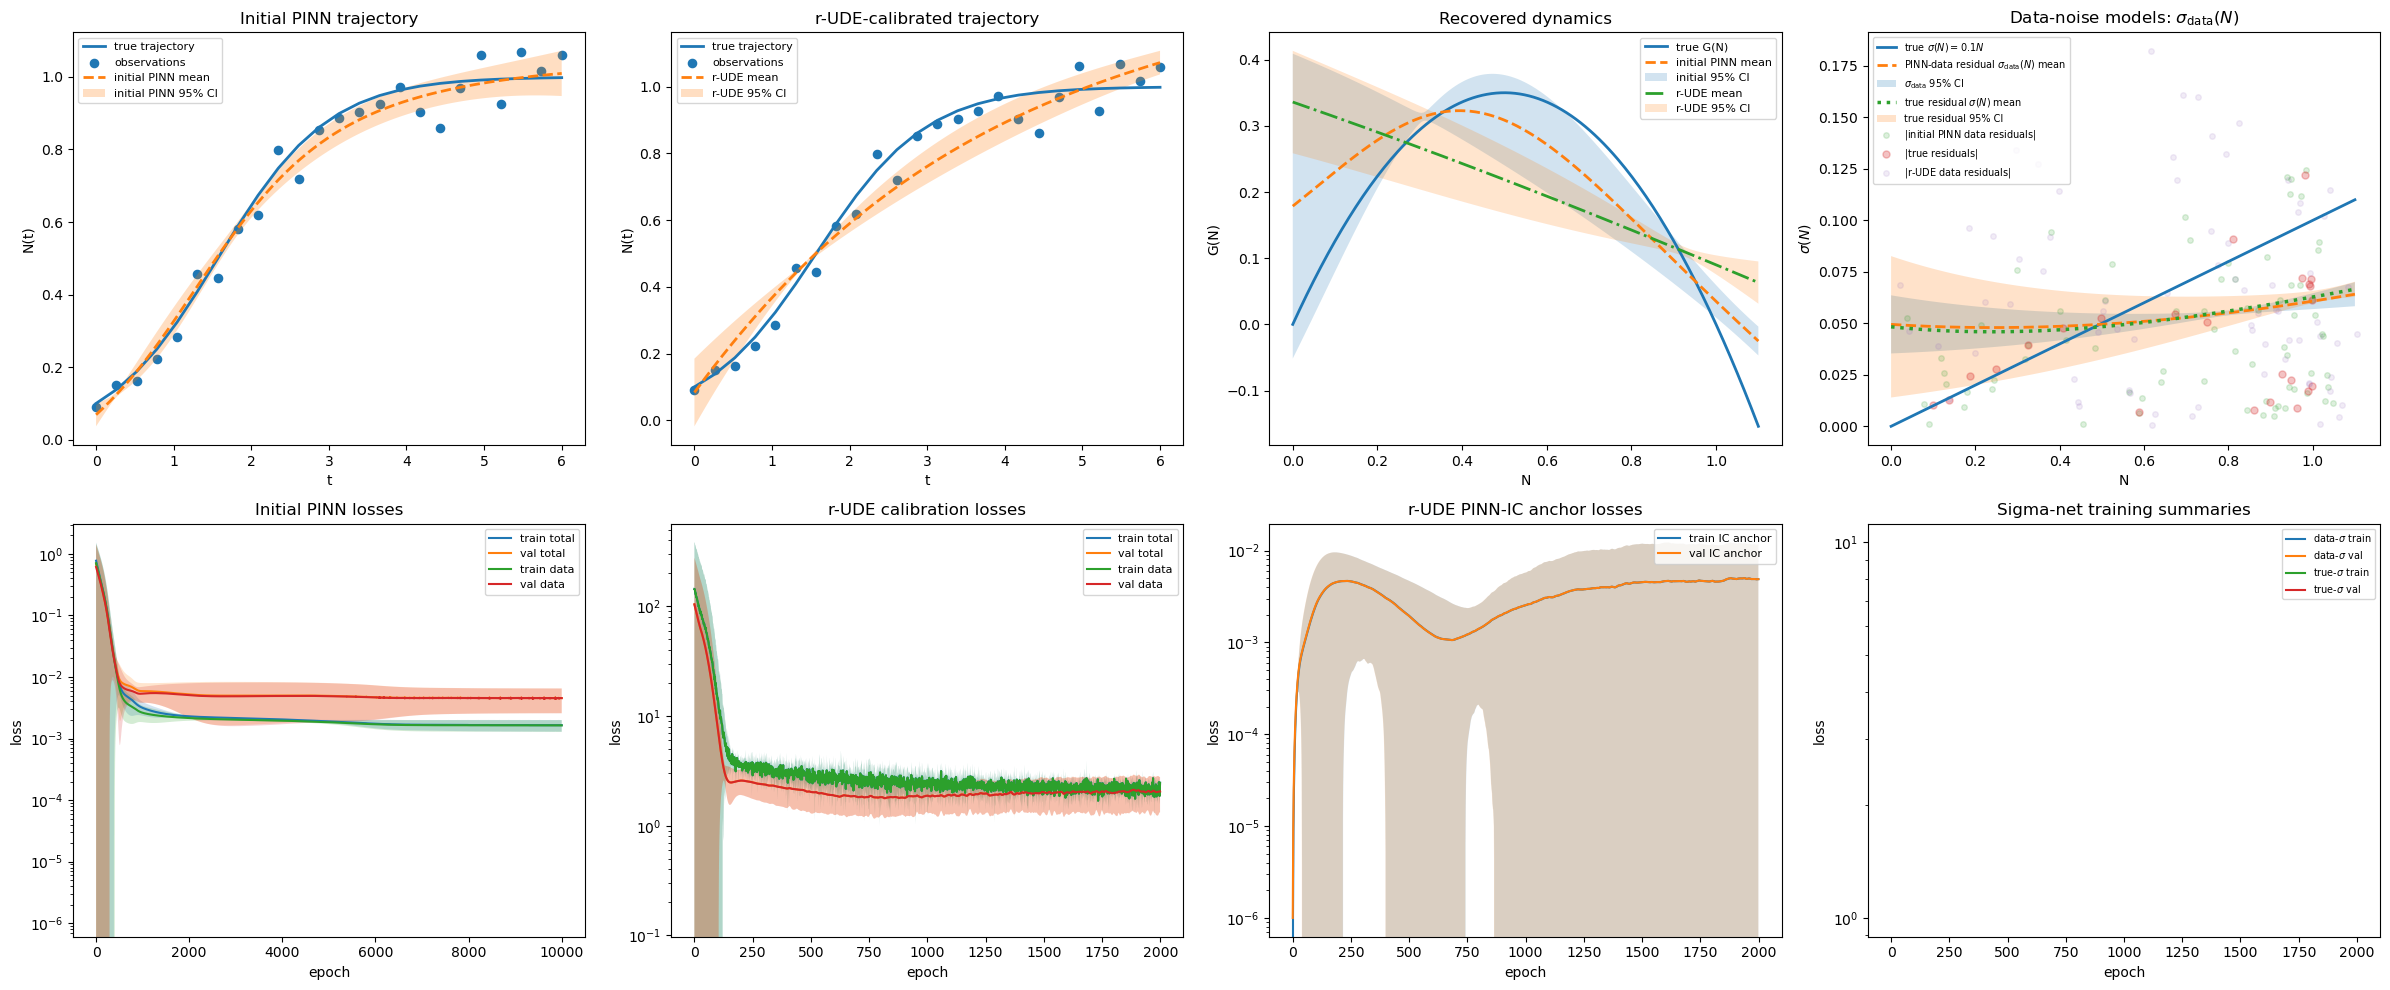

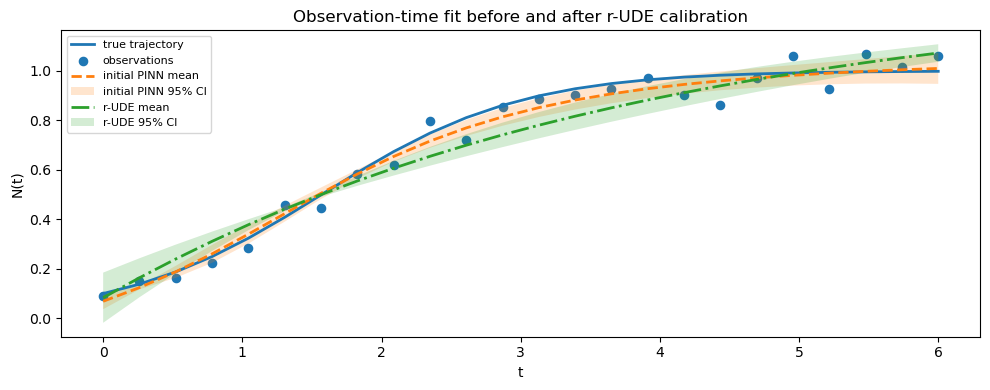


Initial PINN summary
--------------------
Number of PINN splits: 3
Mean best validation loss: 3.880476e-03
Std  best validation loss: 2.178569e-03
Mean best epoch: 4376.00
Std  best epoch: 4874.95

Data-residual sigma summary
---------------------------
Number of sigma repeats: 5
Mean best validation loss: -4.692245e+00
Std  best validation loss: 2.056219e-01
Mean best epoch: 1537.20
Std  best epoch: 640.89

True-residual sigma summary
---------------------------
Number of sigma repeats: 5
Mean best validation loss: -5.190822e+00
Std  best validation loss: 5.147254e-01
Mean best epoch: 1331.60
Std  best epoch: 697.77

r-UDE calibration summary
-------------------------
Number of r-UDE splits: 3
Mean best validation loss: 1.637462e+00
Std  best validation loss: 4.199420e-01
Mean best epoch: 569.67
Std  best epoch: 364.67

PINN-estimated ICs used to initialize / anchor the UDE
Split  1 | PINN IC estimate = 0.090538
Split  2 | PINN IC estimate = 0.036991
Split  3 | PINN IC estimate = 0.0

In [15]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
# ============================================================
r_true = 1.4
N0 = 0.1
numpts = 4 * (24 // 4)

t_obs = torch.linspace(0.0, 6.0, numpts, device=device).view(-1, 1)

def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# 2. Generate synthetic observed data
#    Noise law is heteroscedastic: sigma_true(N) = 0.1 N
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def odeint_rk4(f, y0, t):
    """
    t: shape (T,) increasing
    y0: shape (1, d)
    returns shape (T, 1, d)
    """
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)

with torch.no_grad():
    y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
    y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)

torch.manual_seed(2)
y_data = y_true + 0.1 * torch.randn_like(y_true) * y_true

# evaluation grids
t_plot = torch.linspace(0.0, 6.0, 200, device=device).view(-1, 1)
N_grid = torch.linspace(0.0, 1.1, 200, device=device).view(-1, 1)

with torch.no_grad():
    G_grid_true = G_true(N_grid)
    sigma_true_grid = 0.1 * N_grid


# ============================================================
# 3. Model classes
# ============================================================
class SolutionNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, t):
        return self.net(t)


class DynamicsNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, N):
        return self.net(N)


class SigmaNet(nn.Module):
    def __init__(self, hidden_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
            nn.Softplus(),
        )

    def forward(self, N):
        return self.net(N) + 1e-4


# ============================================================
# 4. Helper functions
# ============================================================
def mean_and_ci(arr, ci=1.96):
    arr = np.array(arr)
    mean = arr.mean(axis=0)
    if arr.shape[0] == 1:
        lo = mean.copy()
        hi = mean.copy()
    else:
        sem = arr.std(axis=0, ddof=1) / np.sqrt(arr.shape[0])
        lo = mean - ci * sem
        hi = mean + ci * sem
    return mean, lo, hi

def gaussian_sigma_nll(resid, sigma):
    sigma2 = sigma ** 2
    return torch.mean(torch.log(sigma2) + (resid ** 2) / sigma2)

def sigma_monotonicity_loss(model, N_col):
    N_req = N_col.clone().detach().requires_grad_(True)
    sigma_col = model(N_req)
    dsigma_dN = torch.autograd.grad(
        outputs=sigma_col,
        inputs=N_req,
        grad_outputs=torch.ones_like(sigma_col),
        create_graph=True,
        retain_graph=True,
    )[0]
    return torch.mean(torch.relu(-dsigma_dN) ** 2)

def pinn_physics_residual(sol_net, dyn_net, t_col):
    N_pred_col = sol_net(t_col)
    dN_dt = torch.autograd.grad(
        outputs=N_pred_col,
        inputs=t_col,
        grad_outputs=torch.ones_like(N_pred_col),
        create_graph=True,
        retain_graph=True,
    )[0]
    rhs_pred = dyn_net(N_pred_col)
    phys_res = dN_dt - rhs_pred
    return N_pred_col, dN_dt, rhs_pred, phys_res

def predict_sigma_ensemble(models, N_in):
    vals = []
    with torch.no_grad():
        for m in models:
            vals.append(m(N_in).detach())
    return torch.stack(vals, dim=0).mean(dim=0)

def fit_sigma_repeated(
    N_all,
    resid_all,
    N_eval_grid,
    N_col_base,
    n_repeats=5,
    val_fraction=0.2,
    n_epochs=3000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="sigma",
):
    n_samples = N_all.shape[0]
    n_val = int(round(val_fraction * n_samples))
    n_val = max(1, min(n_val, n_samples - 1))
    n_train = n_samples - n_val

    train_total_histories = []
    train_nll_histories = []
    train_mon_histories = []

    val_total_histories = []
    val_nll_histories = []
    val_mon_histories = []

    curve_histories = []
    best_val_losses = []
    best_epochs = []
    best_models = []

    for repeat in range(n_repeats):
        g = torch.Generator(device=device)
        g.manual_seed(seed_offset_split + repeat)

        perm = torch.randperm(n_samples, generator=g, device=device)
        train_idx = perm[:n_train].sort().values
        val_idx = perm[n_train:].sort().values

        N_train = N_all[train_idx]
        r_train = resid_all[train_idx]
        N_val = N_all[val_idx]
        r_val = resid_all[val_idx]

        torch.manual_seed(seed_offset_model + repeat)
        np.random.seed(seed_offset_model + repeat)

        sigma_net = SigmaNet(hidden_dim=hidden_dim).to(device)
        opt = torch.optim.Adam(sigma_net.parameters(), lr=lr)

        train_total_history = []
        train_nll_history = []
        train_mon_history = []

        val_total_history = []
        val_nll_history = []
        val_mon_history = []

        best_val_loss = float("inf")
        best_epoch = -1
        best_state = None

        for epoch in range(n_epochs):
            opt.zero_grad()

            sigma_pred_train = sigma_net(N_train)
            train_nll = gaussian_sigma_nll(r_train, sigma_pred_train)
            train_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
            reg = lambda_reg * sum((p ** 2).sum() for p in sigma_net.parameters())

            train_total = train_nll + lambda_mon * train_mon + reg
            train_total.backward()
            opt.step()

            with torch.no_grad():
                sigma_pred_val = sigma_net(N_val)
                val_nll = gaussian_sigma_nll(r_val, sigma_pred_val)

            val_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
            val_total = val_nll + lambda_mon * val_mon

            train_total_history.append(train_total.item())
            train_nll_history.append(train_nll.item())
            train_mon_history.append(train_mon.item())

            val_total_history.append(val_total.item())
            val_nll_history.append(val_nll.item())
            val_mon_history.append(val_mon.item())

            if val_total.item() < best_val_loss:
                best_val_loss = val_total.item()
                best_epoch = epoch
                best_state = copy.deepcopy(sigma_net.state_dict())

        sigma_net.load_state_dict(best_state)
        sigma_net.eval()

        with torch.no_grad():
            sigma_curve = sigma_net(N_eval_grid).squeeze(1).cpu().numpy()

        best_models.append(copy.deepcopy(sigma_net))
        train_total_histories.append(train_total_history)
        train_nll_histories.append(train_nll_history)
        train_mon_histories.append(train_mon_history)

        val_total_histories.append(val_total_history)
        val_nll_histories.append(val_nll_history)
        val_mon_histories.append(val_mon_history)

        curve_histories.append(sigma_curve)
        best_val_losses.append(best_val_loss)
        best_epochs.append(best_epoch)

        print(
            f"{label} repeat {repeat + 1:2d}/{n_repeats} done | "
            f"Best epoch = {best_epoch:4d} | Best val loss = {best_val_loss:.6e}"
        )

    return {
        "train_total_histories": np.array(train_total_histories),
        "train_nll_histories": np.array(train_nll_histories),
        "train_mon_histories": np.array(train_mon_histories),
        "val_total_histories": np.array(val_total_histories),
        "val_nll_histories": np.array(val_nll_histories),
        "val_mon_histories": np.array(val_mon_histories),
        "curve_histories": np.array(curve_histories),
        "best_val_losses": np.array(best_val_losses),
        "best_epochs": np.array(best_epochs),
        "best_models": best_models,
    }

def ude_rollout(dyn_net, y0, t):
    """
    dyn_net: N -> dN/dt
    y0: shape (1,1)
    t: shape (T,1) or (T,)
    returns shape (T,1)
    """
    t_vec = t.squeeze()
    traj = odeint_rk4(lambda tt, y: dyn_net(y), y0, t_vec).squeeze(1)
    return traj


# ============================================================
# 5. Initial PINN fit across train/validation splits
# ============================================================
n_col = 1000
t_col_base = torch.linspace(0.0, 6.0, n_col, device=device).view(-1, 1)

n_epochs = 10000
n_splits = 3

val_fraction = 0.2
n_obs = t_obs.shape[0]
n_val = int(round(val_fraction * n_obs))
n_train = n_obs - n_val

lambda_phys = 1.0
lambda_ic = 0.0

learning_rate = 1e-3
hidden_dim_sol = 4
hidden_dim_dyn = 4

train_total_histories = []
train_data_histories = []
train_phys_histories = []

val_total_histories = []
val_data_histories = []
val_phys_histories = []

traj_histories = []
rhs_histories = []
obs_fit_histories = []

best_val_losses = []
best_epochs = []

best_initial_states = []

for split in range(n_splits):
    g = torch.Generator(device=device)
    g.manual_seed(1000 + split)

    perm = torch.randperm(n_obs, generator=g, device=device)
    train_idx = perm[:n_train].sort().values
    val_idx = perm[n_train:].sort().values

    t_train = t_obs[train_idx]
    y_train = y_data[train_idx]

    t_val = t_obs[val_idx]
    y_val = y_data[val_idx]

    torch.manual_seed(1234 + split)
    np.random.seed(1234 + split)

    sol_net = SolutionNet(hidden_dim=hidden_dim_sol).to(device)
    dyn_net = DynamicsNet(hidden_dim=hidden_dim_dyn).to(device)

    optimizer = torch.optim.Adam(
        list(sol_net.parameters()) + list(dyn_net.parameters()),
        lr=learning_rate
    )

    train_total_history = []
    train_data_history = []
    train_phys_history = []

    val_total_history = []
    val_data_history = []
    val_phys_history = []

    best_val_loss = float("inf")
    best_epoch = -1
    best_state = None

    for epoch in range(n_epochs):
        optimizer.zero_grad()

        N_pred_train = sol_net(t_train)
        train_data_loss = torch.mean((N_pred_train - y_train) ** 2)

        t_col = t_col_base.clone().detach().requires_grad_(True)
        _, _, _, phys_res = pinn_physics_residual(sol_net, dyn_net, t_col)
        phys_loss = torch.mean(phys_res ** 2)

        # keep IC unconstrained to match your earlier practice
        train_loss = train_data_loss + lambda_phys * phys_loss
        train_loss.backward()
        optimizer.step()

        with torch.no_grad():
            N_pred_val = sol_net(t_val)
            val_data_loss = torch.mean((N_pred_val - y_val) ** 2)

        t_col_val = t_col_base.clone().detach().requires_grad_(True)
        _, _, _, val_phys_res = pinn_physics_residual(sol_net, dyn_net, t_col_val)
        val_phys_loss = torch.mean(val_phys_res ** 2)
        val_loss = val_data_loss + lambda_phys * val_phys_loss

        train_total_history.append(train_loss.item())
        train_data_history.append(train_data_loss.item())
        train_phys_history.append(phys_loss.item())

        val_total_history.append(val_loss.item())
        val_data_history.append(val_data_loss.item())
        val_phys_history.append(val_phys_loss.item())

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_epoch = epoch
            best_state = {
                "sol_net": copy.deepcopy(sol_net.state_dict()),
                "dyn_net": copy.deepcopy(dyn_net.state_dict()),
            }

    print(
        f"Initial PINN split {split + 1:2d}/{n_splits} done | "
        f"Best epoch = {best_epoch:5d} | Best val loss = {best_val_loss:.6e}"
    )

    sol_net.load_state_dict(best_state["sol_net"])
    dyn_net.load_state_dict(best_state["dyn_net"])
    sol_net.eval()
    dyn_net.eval()

    with torch.no_grad():
        N_pinn = sol_net(t_plot)
        G_grid_learned = dyn_net(N_grid)
        N_fit_obs = sol_net(t_obs)
        # IMPORTANT: UDE IC initialized from corresponding PINN IC estimate, not true N0
        N0_init_for_ude = sol_net(torch.zeros((1, 1), device=device))

    train_total_histories.append(train_total_history)
    train_data_histories.append(train_data_history)
    train_phys_histories.append(train_phys_history)

    val_total_histories.append(val_total_history)
    val_data_histories.append(val_data_history)
    val_phys_histories.append(val_phys_history)

    traj_histories.append(N_pinn.squeeze(1).cpu().numpy())
    rhs_histories.append(G_grid_learned.squeeze(1).cpu().numpy())
    obs_fit_histories.append(N_fit_obs.squeeze(1).cpu().numpy())

    best_val_losses.append(best_val_loss)
    best_epochs.append(best_epoch)

    best_initial_states.append({
        "sol_net": copy.deepcopy(sol_net.state_dict()),
        "dyn_net": copy.deepcopy(dyn_net.state_dict()),
        "y0_ude_init": N0_init_for_ude.detach().clone(),
        "train_idx": train_idx.clone(),
        "val_idx": val_idx.clone(),
    })

train_total_histories = np.array(train_total_histories)
train_data_histories = np.array(train_data_histories)
train_phys_histories = np.array(train_phys_histories)

val_total_histories = np.array(val_total_histories)
val_data_histories = np.array(val_data_histories)
val_phys_histories = np.array(val_phys_histories)

traj_histories = np.array(traj_histories)
rhs_histories = np.array(rhs_histories)
obs_fit_histories = np.array(obs_fit_histories)

traj_mean, traj_lo, traj_hi = mean_and_ci(traj_histories)
rhs_mean, rhs_lo, rhs_hi = mean_and_ci(rhs_histories)
obs_fit_mean, obs_fit_lo, obs_fit_hi = mean_and_ci(obs_fit_histories)


# ============================================================
# 6. Learn sigma_data(N) from PINN data residuals using 5 repeats
#    residual_data = y_data - N_hat_PINN
# ============================================================
with torch.no_grad():
    y_rep = y_data.squeeze(1).cpu().numpy()[None, :]
    resid_pinn_all_np = y_rep - obs_fit_histories

    N_pinn_sigma_all_np = obs_fit_histories.reshape(-1, 1)
    resid_pinn_sigma_all_np = resid_pinn_all_np.reshape(-1, 1)

    mask = N_pinn_sigma_all_np.squeeze() > 0.0
    N_pinn_sigma_all_np = N_pinn_sigma_all_np[mask]
    resid_pinn_sigma_all_np = resid_pinn_sigma_all_np[mask]

N_pinn_sigma_all = torch.tensor(N_pinn_sigma_all_np, dtype=torch.float32, device=device)
resid_pinn_sigma_all = torch.tensor(resid_pinn_sigma_all_np, dtype=torch.float32, device=device)

N_sigma_data_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_pinn_sigma_all.max().item())),
    200,
    device=device
).view(-1, 1)

sigma_data_results = fit_sigma_repeated(
    N_all=N_pinn_sigma_all,
    resid_all=resid_pinn_sigma_all,
    N_eval_grid=N_grid,
    N_col_base=N_sigma_data_col_base,
    n_repeats=5,
    val_fraction=0.2,
    n_epochs=2000,
    lr=1e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="DATA-sigma",
)

sigma_data_mean, sigma_data_lo, sigma_data_hi = mean_and_ci(sigma_data_results["curve_histories"])
sigma_data_models = sigma_data_results["best_models"]


# ============================================================
# 7. Learn sigma_truefit(N) from true residuals using 5 repeats
#    residual_true = y_data - y_true
#    Only for comparison / plotting
# ============================================================
with torch.no_grad():
    N_true_sigma_np = y_true.squeeze(1).cpu().numpy().reshape(-1, 1)
    resid_true_sigma_np = (y_data - y_true).squeeze(1).cpu().numpy().reshape(-1, 1)

    mask_true = N_true_sigma_np.squeeze() > 0.0
    N_true_sigma_np = N_true_sigma_np[mask_true]
    resid_true_sigma_np = resid_true_sigma_np[mask_true]

N_true_sigma = torch.tensor(N_true_sigma_np, dtype=torch.float32, device=device)
resid_true_sigma = torch.tensor(resid_true_sigma_np, dtype=torch.float32, device=device)

N_true_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_true_sigma.max().item())),
    200,
    device=device
).view(-1, 1)

sigma_truefit_results = fit_sigma_repeated(
    N_all=N_true_sigma,
    resid_all=resid_true_sigma,
    N_eval_grid=N_grid,
    N_col_base=N_true_sigma_col_base,
    n_repeats=5,
    val_fraction=0.2,
    n_epochs=2000,
    lr=1e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=9000,
    seed_offset_model=11000,
    label="TRUE-sigma",
)

sigma_truefit_mean, sigma_truefit_lo, sigma_truefit_hi = mean_and_ci(
    sigma_truefit_results["curve_histories"]
)


# ============================================================
# 8. r-UDE calibration stage
#    Uses a neural ODE with data loss augmented by learned sigma
#    UDE dynamics initialized from corresponding initial PINN dynamics
#    UDE initial condition initialized from corresponding PINN IC estimate
#    NO true N0 is used in the calibration loss
# ============================================================
rUDE_epochs = 2000
rUDE_lr = 1e-3
rUDE_num_noise_realizations = 4
rUDE_data_scale = 1.0
rUDE_lambda_ic_anchor = 1.0
rUDE_lambda_reg = 1e-6

utrain_total_histories = []
utrain_data_histories = []
utrain_ic_anchor_histories = []

uval_total_histories = []
uval_data_histories = []
uval_ic_anchor_histories = []

utraj_histories = []
urhs_histories = []
uobs_fit_histories = []

ubest_val_losses = []
ubest_epochs = []

best_rude_states = []

for split in range(n_splits):
    train_idx = best_initial_states[split]["train_idx"]
    val_idx = best_initial_states[split]["val_idx"]

    y_train = y_data[train_idx]
    y_val = y_data[val_idx]

    torch.manual_seed(20000 + split)
    np.random.seed(20000 + split)

    # UDE dynamics net initialized from corresponding PINN dynamics net
    dyn_net = DynamicsNet(hidden_dim=hidden_dim_dyn).to(device)
    #dyn_net.load_state_dict(best_initial_states[split]["dyn_net"])

    # UDE initial condition initialized from corresponding PINN IC estimate
    y0_pinn_anchor = best_initial_states[split]["y0_ude_init"].detach().clone()
    y0_param = nn.Parameter(y0_pinn_anchor.clone())

    optimizer = torch.optim.Adam(
        list(dyn_net.parameters()) + [y0_param],
        lr=rUDE_lr
    )

    utrain_total_history = []
    utrain_data_history = []
    utrain_ic_anchor_history = []

    uval_total_history = []
    uval_data_history = []
    uval_ic_anchor_history = []

    best_val_loss = float("inf")
    best_epoch = -1
    best_state = None

    for epoch in range(rUDE_epochs):
        optimizer.zero_grad()

        # Roll out full trajectory once for current parameters
        y0_current = y0_param
        N_pred_full = ude_rollout(dyn_net, y0_current, t_obs)  # (n_obs, 1)

        N_pred_train = N_pred_full[train_idx]

        # Ensemble sigma_data evaluated at current predicted state
        with torch.no_grad():
            sigma_data_train = predict_sigma_ensemble(
                sigma_data_models,
                torch.clamp(N_pred_train.detach(), min=0.0, max=1.5)
            )
            sigma_data_train = torch.clamp(sigma_data_train, min=1e-4)

        data_loss_mc = 0.0
        for _ in range(rUDE_num_noise_realizations):
            eps_d = torch.randn_like(y_train)
            y_noisy = y_train + rUDE_data_scale * sigma_data_train * eps_d
            data_loss_mc = data_loss_mc + torch.mean(
                ((N_pred_train - y_noisy) / sigma_data_train) ** 2
            )
        data_loss_mc = data_loss_mc / rUDE_num_noise_realizations

        # Anchor the UDE IC to the corresponding PINN-estimated IC,
        # not to the true N0.
        ic_anchor_loss = torch.mean((y0_current - y0_pinn_anchor) ** 2)

        reg_loss = rUDE_lambda_reg * sum((p ** 2).sum() for p in dyn_net.parameters())

        train_loss = data_loss_mc + rUDE_lambda_ic_anchor * ic_anchor_loss + reg_loss
        train_loss.backward()
        optimizer.step()

        # validation
        with torch.no_grad():
            y0_val = y0_param
            N_pred_full_val = ude_rollout(dyn_net, y0_val, t_obs)
            N_pred_val = N_pred_full_val[val_idx]

            sigma_data_val = predict_sigma_ensemble(
                sigma_data_models,
                torch.clamp(N_pred_val, min=0.0, max=1.5)
            )
            sigma_data_val = torch.clamp(sigma_data_val, min=1e-4)

            val_data_loss = torch.mean(((N_pred_val - y_val) / sigma_data_val) ** 2)
            val_ic_anchor_loss = torch.mean((y0_val - y0_pinn_anchor) ** 2)
            val_loss = val_data_loss + rUDE_lambda_ic_anchor * val_ic_anchor_loss

        utrain_total_history.append(train_loss.item())
        utrain_data_history.append(data_loss_mc.item())
        utrain_ic_anchor_history.append(ic_anchor_loss.item())

        uval_total_history.append(val_loss.item())
        uval_data_history.append(val_data_loss.item())
        uval_ic_anchor_history.append(val_ic_anchor_loss.item())

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_epoch = epoch
            best_state = {
                "dyn_net": copy.deepcopy(dyn_net.state_dict()),
                "y0_param": y0_val.detach().clone(),
                "y0_pinn_anchor": y0_pinn_anchor.detach().clone(),
            }

    print(
        f"r-UDE calibration split {split + 1:2d}/{n_splits} done | "
        f"Best epoch = {best_epoch:5d} | Best val loss = {best_val_loss:.6e}"
    )

    dyn_net.load_state_dict(best_state["dyn_net"])
    y0_best = best_state["y0_param"]
    dyn_net.eval()

    with torch.no_grad():
        N_rude = ude_rollout(dyn_net, y0_best, t_plot)
        G_grid_ulearned = dyn_net(N_grid)
        N_ufit_obs = ude_rollout(dyn_net, y0_best, t_obs)

    utrain_total_histories.append(utrain_total_history)
    utrain_data_histories.append(utrain_data_history)
    utrain_ic_anchor_histories.append(utrain_ic_anchor_history)

    uval_total_histories.append(uval_total_history)
    uval_data_histories.append(uval_data_history)
    uval_ic_anchor_histories.append(uval_ic_anchor_history)

    utraj_histories.append(N_rude.squeeze(1).cpu().numpy())
    urhs_histories.append(G_grid_ulearned.squeeze(1).cpu().numpy())
    uobs_fit_histories.append(N_ufit_obs.squeeze(1).cpu().numpy())

    ubest_val_losses.append(best_val_loss)
    ubest_epochs.append(best_epoch)

    best_rude_states.append({
        "dyn_net": copy.deepcopy(dyn_net.state_dict()),
        "y0_param": y0_best.detach().clone(),
        "y0_pinn_anchor": best_state["y0_pinn_anchor"].detach().clone(),
    })

utrain_total_histories = np.array(utrain_total_histories)
utrain_data_histories = np.array(utrain_data_histories)
utrain_ic_anchor_histories = np.array(utrain_ic_anchor_histories)

uval_total_histories = np.array(uval_total_histories)
uval_data_histories = np.array(uval_data_histories)
uval_ic_anchor_histories = np.array(uval_ic_anchor_histories)

utraj_histories = np.array(utraj_histories)
urhs_histories = np.array(urhs_histories)
uobs_fit_histories = np.array(uobs_fit_histories)

utraj_mean, utraj_lo, utraj_hi = mean_and_ci(utraj_histories)
urhs_mean, urhs_lo, urhs_hi = mean_and_ci(urhs_histories)
uobs_fit_mean, uobs_fit_lo, uobs_fit_hi = mean_and_ci(uobs_fit_histories)


# ============================================================
# 9. Post-calibration residual checks
# ============================================================
with torch.no_grad():
    resid_after_rude_np = y_data.squeeze(1).cpu().numpy()[None, :] - uobs_fit_histories
    N_after_rude_np = uobs_fit_histories.reshape(-1, 1)
    resid_after_rude_flat_np = resid_after_rude_np.reshape(-1, 1)

    mask = N_after_rude_np.squeeze() > 0.0
    N_after_rude_np = N_after_rude_np[mask]
    resid_after_rude_flat_np = resid_after_rude_flat_np[mask]


# ============================================================
# 10. Plots
# ============================================================
fig, axes = plt.subplots(2, 4, figsize=(24, 10))

# ------------------------------------------------------------
# Initial PINN trajectory
# ------------------------------------------------------------
axes[0, 0].plot(
    t_obs.cpu().numpy(),
    y_true.squeeze(1).cpu().numpy(),
    label="true trajectory",
    linewidth=2,
)
axes[0, 0].scatter(
    t_obs.cpu().numpy(),
    y_data.squeeze(1).cpu().numpy(),
    label="observations",
    s=35,
)
axes[0, 0].plot(
    t_plot.cpu().numpy(),
    traj_mean,
    "--",
    linewidth=2,
    label="initial PINN mean",
)
axes[0, 0].fill_between(
    t_plot.squeeze(1).cpu().numpy(),
    traj_lo,
    traj_hi,
    alpha=0.25,
    label="initial PINN 95% CI",
)
axes[0, 0].set_xlabel("t")
axes[0, 0].set_ylabel("N(t)")
axes[0, 0].set_title("Initial PINN trajectory")
axes[0, 0].legend(fontsize=8)

# ------------------------------------------------------------
# r-UDE-calibrated trajectory
# ------------------------------------------------------------
axes[0, 1].plot(
    t_obs.cpu().numpy(),
    y_true.squeeze(1).cpu().numpy(),
    label="true trajectory",
    linewidth=2,
)
axes[0, 1].scatter(
    t_obs.cpu().numpy(),
    y_data.squeeze(1).cpu().numpy(),
    label="observations",
    s=35,
)
axes[0, 1].plot(
    t_plot.cpu().numpy(),
    utraj_mean,
    "--",
    linewidth=2,
    label="r-UDE mean",
)
axes[0, 1].fill_between(
    t_plot.squeeze(1).cpu().numpy(),
    utraj_lo,
    utraj_hi,
    alpha=0.25,
    label="r-UDE 95% CI",
)
axes[0, 1].set_xlabel("t")
axes[0, 1].set_ylabel("N(t)")
axes[0, 1].set_title("r-UDE-calibrated trajectory")
axes[0, 1].legend(fontsize=8)

# ------------------------------------------------------------
# Dynamics before / after calibration
# ------------------------------------------------------------
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    G_grid_true.squeeze(1).cpu().numpy(),
    label="true G(N)",
    linewidth=2,
)
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    rhs_mean,
    "--",
    linewidth=2,
    label="initial PINN mean",
)
axes[0, 2].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    rhs_lo,
    rhs_hi,
    alpha=0.20,
    label="initial 95% CI",
)
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    urhs_mean,
    "-.",
    linewidth=2,
    label="r-UDE mean",
)
axes[0, 2].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    urhs_lo,
    urhs_hi,
    alpha=0.20,
    label="r-UDE 95% CI",
)
axes[0, 2].set_xlabel("N")
axes[0, 2].set_ylabel("G(N)")
axes[0, 2].set_title("Recovered dynamics")
axes[0, 2].legend(fontsize=8)

# ------------------------------------------------------------
# sigma_data(N) compared with sigma_truefit(N)
# ------------------------------------------------------------
axes[0, 3].plot(
    N_grid.cpu().numpy(),
    sigma_true_grid.squeeze(1).cpu().numpy(),
    linewidth=2,
    label=r"true $\sigma(N)=0.1N$",
)
axes[0, 3].plot(
    N_grid.cpu().numpy(),
    sigma_data_mean,
    "--",
    linewidth=2,
    label=r"PINN-data residual $\sigma_{\mathrm{data}}(N)$ mean",
)
axes[0, 3].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_data_lo,
    sigma_data_hi,
    alpha=0.22,
    label=r"$\sigma_{\mathrm{data}}$ 95% CI",
)
axes[0, 3].plot(
    N_grid.cpu().numpy(),
    sigma_truefit_mean,
    ":",
    linewidth=2.5,
    label=r"true residual $\sigma(N)$ mean",
)
axes[0, 3].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_truefit_lo,
    sigma_truefit_hi,
    alpha=0.22,
    label="true residual 95% CI",
)
axes[0, 3].scatter(
    N_pinn_sigma_all.cpu().numpy().squeeze(),
    np.abs(resid_pinn_sigma_all.cpu().numpy().squeeze()),
    s=16,
    alpha=0.16,
    label=r"$|$initial PINN data residuals$|$",
)
axes[0, 3].scatter(
    N_true_sigma.cpu().numpy().squeeze(),
    np.abs(resid_true_sigma.cpu().numpy().squeeze()),
    s=26,
    alpha=0.28,
    label=r"$|$true residuals$|$",
)
axes[0, 3].scatter(
    N_after_rude_np.squeeze(),
    np.abs(resid_after_rude_flat_np.squeeze()),
    s=16,
    alpha=0.12,
    label=r"$|$r-UDE data residuals$|$",
)
axes[0, 3].set_xlabel("N")
axes[0, 3].set_ylabel(r"$\sigma(N)$")
axes[0, 3].set_title(r"Data-noise models: $\sigma_{\mathrm{data}}(N)$")
axes[0, 3].legend(fontsize=7)

# ------------------------------------------------------------
# Initial PINN losses
# ------------------------------------------------------------
epochs_init = np.arange(n_epochs)
train_total_mean, train_total_lo, train_total_hi = mean_and_ci(train_total_histories)
val_total_mean, val_total_lo, val_total_hi = mean_and_ci(val_total_histories)
train_data_mean, train_data_lo, train_data_hi = mean_and_ci(train_data_histories)
val_data_mean, val_data_lo, val_data_hi = mean_and_ci(val_data_histories)

axes[1, 0].plot(epochs_init, train_total_mean, label="train total")
axes[1, 0].fill_between(epochs_init, train_total_lo, train_total_hi, alpha=0.2)
axes[1, 0].plot(epochs_init, val_total_mean, label="val total")
axes[1, 0].fill_between(epochs_init, val_total_lo, val_total_hi, alpha=0.2)
axes[1, 0].plot(epochs_init, train_data_mean, label="train data")
axes[1, 0].fill_between(epochs_init, train_data_lo, train_data_hi, alpha=0.2)
axes[1, 0].plot(epochs_init, val_data_mean, label="val data")
axes[1, 0].fill_between(epochs_init, val_data_lo, val_data_hi, alpha=0.2)
axes[1, 0].set_yscale("log")
axes[1, 0].set_xlabel("epoch")
axes[1, 0].set_ylabel("loss")
axes[1, 0].set_title("Initial PINN losses")
axes[1, 0].legend(fontsize=8)

# ------------------------------------------------------------
# r-UDE losses
# ------------------------------------------------------------
epochs_u = np.arange(rUDE_epochs)
utrain_total_mean, utrain_total_lo, utrain_total_hi = mean_and_ci(utrain_total_histories)
uval_total_mean, uval_total_lo, uval_total_hi = mean_and_ci(uval_total_histories)
utrain_data_mean, utrain_data_lo, utrain_data_hi = mean_and_ci(utrain_data_histories)
uval_data_mean, uval_data_lo, uval_data_hi = mean_and_ci(uval_data_histories)

axes[1, 1].plot(epochs_u, utrain_total_mean, label="train total")
axes[1, 1].fill_between(epochs_u, utrain_total_lo, utrain_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_u, uval_total_mean, label="val total")
axes[1, 1].fill_between(epochs_u, uval_total_lo, uval_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_u, utrain_data_mean, label="train data")
axes[1, 1].fill_between(epochs_u, utrain_data_lo, utrain_data_hi, alpha=0.2)
axes[1, 1].plot(epochs_u, uval_data_mean, label="val data")
axes[1, 1].fill_between(epochs_u, uval_data_lo, uval_data_hi, alpha=0.2)
axes[1, 1].set_yscale("log")
axes[1, 1].set_xlabel("epoch")
axes[1, 1].set_ylabel("loss")
axes[1, 1].set_title("r-UDE calibration losses")
axes[1, 1].legend(fontsize=8)

# ------------------------------------------------------------
# r-UDE IC anchor losses
# ------------------------------------------------------------
utrain_ic_mean, utrain_ic_lo, utrain_ic_hi = mean_and_ci(utrain_ic_anchor_histories)
uval_ic_mean, uval_ic_lo, uval_ic_hi = mean_and_ci(uval_ic_anchor_histories)

axes[1, 2].plot(epochs_u, utrain_ic_mean, label="train IC anchor")
axes[1, 2].fill_between(epochs_u, utrain_ic_lo, utrain_ic_hi, alpha=0.2)
axes[1, 2].plot(epochs_u, uval_ic_mean, label="val IC anchor")
axes[1, 2].fill_between(epochs_u, uval_ic_lo, uval_ic_hi, alpha=0.2)
axes[1, 2].set_yscale("log")
axes[1, 2].set_xlabel("epoch")
axes[1, 2].set_ylabel("loss")
axes[1, 2].set_title("r-UDE PINN-IC anchor losses")
axes[1, 2].legend(fontsize=8)

# ------------------------------------------------------------
# sigma training losses
# ------------------------------------------------------------
sigma_epochs = np.arange(sigma_data_results["train_total_histories"].shape[1])

sigma_data_train_mean, _, _ = mean_and_ci(sigma_data_results["train_total_histories"])
sigma_data_val_mean, _, _ = mean_and_ci(sigma_data_results["val_total_histories"])
sigma_true_train_mean, _, _ = mean_and_ci(sigma_truefit_results["train_total_histories"])
sigma_true_val_mean, _, _ = mean_and_ci(sigma_truefit_results["val_total_histories"])

axes[1, 3].plot(sigma_epochs, sigma_data_train_mean, label=r"data-$\sigma$ train")
axes[1, 3].plot(sigma_epochs, sigma_data_val_mean, label=r"data-$\sigma$ val")
axes[1, 3].plot(sigma_epochs, sigma_true_train_mean, label=r"true-$\sigma$ train")
axes[1, 3].plot(sigma_epochs, sigma_true_val_mean, label=r"true-$\sigma$ val")
axes[1, 3].set_yscale("log")
axes[1, 3].set_xlabel("epoch")
axes[1, 3].set_ylabel("loss")
axes[1, 3].set_title("Sigma-net training summaries")
axes[1, 3].legend(fontsize=7)

plt.tight_layout()
plt.show()


# ============================================================
# 11. Observation-time comparison
# ============================================================
plt.figure(figsize=(10, 4))
plt.plot(
    t_obs.cpu().numpy(),
    y_true.squeeze(1).cpu().numpy(),
    label="true trajectory",
    linewidth=2,
)
plt.scatter(
    t_obs.cpu().numpy(),
    y_data.squeeze(1).cpu().numpy(),
    label="observations",
    s=35,
)
plt.plot(
    t_obs.cpu().numpy(),
    obs_fit_mean,
    "--",
    linewidth=2,
    label="initial PINN mean",
)
plt.fill_between(
    t_obs.squeeze(1).cpu().numpy(),
    obs_fit_lo,
    obs_fit_hi,
    alpha=0.20,
    label="initial PINN 95% CI",
)
plt.plot(
    t_obs.cpu().numpy(),
    uobs_fit_mean,
    "-.",
    linewidth=2,
    label="r-UDE mean",
)
plt.fill_between(
    t_obs.squeeze(1).cpu().numpy(),
    uobs_fit_lo,
    uobs_fit_hi,
    alpha=0.20,
    label="r-UDE 95% CI",
)
plt.xlabel("t")
plt.ylabel("N(t)")
plt.title("Observation-time fit before and after r-UDE calibration")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# 12. Summary
# ============================================================
print("\nInitial PINN summary")
print("--------------------")
print(f"Number of PINN splits: {n_splits}")
print(f"Mean best validation loss: {np.mean(best_val_losses):.6e}")
print(f"Std  best validation loss: {np.std(best_val_losses, ddof=1):.6e}")
print(f"Mean best epoch: {np.mean(best_epochs):.2f}")
print(f"Std  best epoch: {np.std(best_epochs, ddof=1):.2f}")

print("\nData-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_data_results['best_val_losses'])}")
print(f"Mean best validation loss: {sigma_data_results['best_val_losses'].mean():.6e}")
print(f"Std  best validation loss: {sigma_data_results['best_val_losses'].std(ddof=1):.6e}")
print(f"Mean best epoch: {sigma_data_results['best_epochs'].mean():.2f}")
print(f"Std  best epoch: {sigma_data_results['best_epochs'].std(ddof=1):.2f}")

print("\nTrue-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_truefit_results['best_val_losses'])}")
print(f"Mean best validation loss: {sigma_truefit_results['best_val_losses'].mean():.6e}")
print(f"Std  best validation loss: {sigma_truefit_results['best_val_losses'].std(ddof=1):.6e}")
print(f"Mean best epoch: {sigma_truefit_results['best_epochs'].mean():.2f}")
print(f"Std  best epoch: {sigma_truefit_results['best_epochs'].std(ddof=1):.2f}")

print("\nr-UDE calibration summary")
print("-------------------------")
print(f"Number of r-UDE splits: {n_splits}")
print(f"Mean best validation loss: {np.mean(ubest_val_losses):.6e}")
print(f"Std  best validation loss: {np.std(ubest_val_losses, ddof=1):.6e}")
print(f"Mean best epoch: {np.mean(ubest_epochs):.2f}")
print(f"Std  best epoch: {np.std(ubest_epochs, ddof=1):.2f}")

print("\nPINN-estimated ICs used to initialize / anchor the UDE")
for i, state in enumerate(best_initial_states, start=1):
    print(f"Split {i:2d} | PINN IC estimate = {state['y0_ude_init'].item():.6f}")

print("\nObserved time points: initial PINN mean vs r-UDE mean")
for ti, yt, yd, mu0, mu1 in zip(
    t_obs.squeeze(1).cpu().numpy(),
    y_true.squeeze(1).cpu().numpy(),
    y_data.squeeze(1).cpu().numpy(),
    obs_fit_mean,
    uobs_fit_mean,
):
    print(
        f"t = {ti:6.3f} | true = {yt:8.5f} | data = {yd:8.5f} | "
        f"PINN = {mu0:8.5f} | r-UDE = {mu1:8.5f}"
    )